![alt text](pic1.jpg "TITLE")

# GDE - Mérnökinformatika MSc - BigData és MI tárgyakhoz kapcsolódó beadandó

Készült: 2026.04.19-24.

Készítették, hozzájárultak:

1) Buda Ádám
2) Cseh István Tamás
3) Józsa Krisztián
4) Plézer Mátyás

=============================================================================================================

Cél: Megvizsgálni, hogy a gazdasági teljesítmény (GDP) és az előzetes oktatási mutatók (érettségi) mennyire pontosan jelzik előre a diplomások számát.

Hipotézis: A diplomások száma egy késleltetett indikátor, amelyet a 4-5 évvel korábbi GDP és az akkori érettségizettek száma határoz meg leginkább.

=============================================================================================================


Feladatkiírás alapján: használjuk a CRISP DM módszertant

1) Understand the shape of the data (Histograms, box plots, etc.)
2) Data Cleaning
3) Data Exploration
4) Feature Engineering
5) Data Preprocessing for Model
6) Basic Model Building
7) Model Tuning
8) Ensemble Modle Building
9) Results

![alt text](crisp-dm.png "CRISP")

# Felhasznált adatsorok:

1) 21.1.1.2. A bruttó hazai termék, a fogyasztás és a felhalmozás hosszú idősora [forrás: https://www.ksh.hu/stadat_files/gdp/hu/gdp0002.html]
2) 21.1.1.3. Az egy főre jutó reáljövedelem és fogyasztás indexének hosszú idősora [forrás: https://www.ksh.hu/stadat_files/gdp/hu/gdp0003.html]
3) 21.1.1.41. A háztartások fogyasztási kiadásának volumenindexei rendeltetés szerinti (COICOP) bontásban (előző év = 100,0%) [forrás: https://www.ksh.hu/stadat_files/gdp/hu/gdp0041.html]
4) 23.1.1.1. Az oktatás főbb, hosszú idősoros adatai (ezer fő) [forrás: https://www.ksh.hu/stadat_files/okt/hu/okt0001.html]
5) 23.1.1.21. Felsőfokú alap- és mesterképzés [forrás: https://www.ksh.hu/stadat_files/okt/hu/okt0021.html]



# Alapvető importok és csomagok telepítése

In [2264]:
# Several helpful packages to load

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [2265]:
!pip install scikit-learn


In [2266]:
import sklearn as sklearn


In [2267]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score


In [2268]:
!pip install xgboost


In [2269]:
import xgboost as xgboost


# AZ XLSX ADATSOROK BEOLVASÁSA egymás után 

In [2270]:
# Adatsor beolvasás GDP 21.1.1.2, fejléc első sorának skippelése
gdp_df1 = pd.read_excel('stadat-gdp0002-21.1.1.2-hu.xlsx', skiprows=1) 


In [2271]:
# Adatsor beolvasás GDP 21.1.1.3, fejléc első sorának skippelése
gdp_df2 = pd.read_excel('stadat-gdp0003-21.1.1.3-hu.xlsx', skiprows=1) 


In [2272]:
# Adatsor beolvasás Oktatás 23.1.1.41, fejléc első sorának skippelése
gdp_df3 = pd.read_excel('stadat-gdp0041-21.1.1.41-hu.xlsx', skiprows=1) 


In [2273]:
# Adatsor beolvasás Oktatás 23.1.1.1, fejléc első sorának skippelése
okt_df1 = pd.read_excel('stadat-okt0001-23.1.1.1-hu.xlsx', skiprows=1) 


In [2274]:
# Adatsor beolvasás Oktatás 23.1.1.21, fejléc első sorának skippelése
okt_df2 = pd.read_excel('stadat-okt0021-23.1.1.21-hu.xlsx', skiprows=1) 


# Adatok megértése

Ebben a lépésben első körben a vizsgálni készült adatokról szeretnénk további információkat kapni, ezért alapvető vizsgálatokat végzünk az egyes adatsorokon, vizsgáljuk a hiányzó adatokat, gyakoriságokat, statisztikákat.

A vizsgálat eredményeit táblázatosan, valamint grafikusan jelenítjük meg (histogramok, boxplots, heatmap, etc.)


A vizsgálathoz először néhány alapvető vizsgálatokat végző függvényeket készítünk el, ez kerül futtatásra mindegyik adatsorra, külön-külön.

In [2275]:
# 1. Missing Data (Hiányzó adatok)

def initial_ana1(df, title):
    print(f"--- {title} ELEMZÉSE ---")
    print("\nHiányzó adatok száma:")
    print(df.isnull().sum())


In [2276]:
# 2. Value Counts (Gyakoriság - főleg kategóriáknál vagy éveknél hasznos)
# Itt ellenőrizhetjük, hogy minden évből csak egy van-e

def initial_ana2(df, title):
    print(f"--- {title} ELEMZÉSE ---")
    print("\nÉvek gyakorisága:")
    print(df.iloc[:,0].value_counts())


In [2277]:
# 3. Statisztikai jellemzők (Describe)

def initial_ana3(df, title):
    print(f"--- {title} ELEMZÉSE ---")
    print("\nLeíró statisztika:")
    display(df.describe())


In [2278]:
# 4. Histograms and Boxplots (Distribution and outliers)
# Only for numeric columns

def initial_ana4(df, title):
    print(f"--- {title} ELEMZESE ---")
    numeric_cols = df.select_dtypes(include=[np.number]).columns
    if len(numeric_cols) == 0:
        print("Nincs numerikus oszlop a histogramokhoz es boxplotokhoz.")
        return
    fig, axes = plt.subplots(len(numeric_cols), 2, figsize=(12, 4 * len(numeric_cols)))
    if len(numeric_cols) == 1:
        axes = np.array([axes])
    for i, col in enumerate(numeric_cols):
        sns.histplot(df[col].dropna(), kde=True, ax=axes[i, 0], color="skyblue")
        axes[i, 0].set_title(f"{col} eloszlasa")
        sns.boxplot(x=df[col].dropna(), ax=axes[i, 1], color="lightcoral")
        axes[i, 1].set_title(f"{col} szelsoertekei")
    plt.tight_layout()
    plt.show()


In [2279]:
# 5. Correlation (Relationship between numeric variables)

def initial_ana5(df, title):
    print(f"--- {title} ELEMZESE ---")
    numeric_cols = df.select_dtypes(include=[np.number]).columns
    if len(numeric_cols) > 1:
        plt.figure(figsize=(8, 6))
        corr_df = df[numeric_cols].corr()
        sns.heatmap(corr_df, annot=True, cmap="coolwarm")
        plt.title(f"Korrelacio: {title}")
        plt.show()
    else:
        print("Nincs eleg numerikus oszlop a korrelaciohoz.")


# Futtatás az egyes adatsorokon - CHECK STEP #1 - Hiányzó adatok

In [2280]:
initial_ana1(gdp_df1, "Bruttó hazai termék")


--- Bruttó hazai termék ELEMZÉSE ---

Hiányzó adatok száma:
Év                                                                          0
Bruttó hazai termék (GDP), 1960 = 100%                                      0
Végső fogyasztás összesen, \n1960 = 100%                                    0
Végső fogyasztás, ebből háztartások tényleges fogyasztása, \n1960 = 100%    0
Bruttó felhalmozás összesen, \n1960 = 100%                                  0
Bruttó felhalmozás, ebből állóeszközök felhalmozása, \n1960 = 100%          0
dtype: int64


In [2281]:
initial_ana1(gdp_df2, "Az egy főre jutó reáljövedelem és fogyasztás")


--- Az egy főre jutó reáljövedelem és fogyasztás ELEMZÉSE ---

Hiányzó adatok száma:
Év                                                   0
Egy főre jutó reáljövedelem indexe, \n1960 = 100%    0
Egy főre jutó fogyasztás indexe, \n1960 = 100%       0
dtype: int64


In [2282]:
initial_ana1(gdp_df3, "A háztartások fogyasztási kiadásának volumenindexei rendeltetés szerint")


--- A háztartások fogyasztási kiadásának volumenindexei rendeltetés szerint ELEMZÉSE ---

Hiányzó adatok száma:
COICOP-csoport    0
1996              0
1997              0
1998              0
1999              0
2000              0
2001              0
2002              0
2003              0
2004              0
2005              0
2006              0
2007              0
2008              0
2009              0
2010              0
2011              0
2012              0
2013              0
2014              0
2015              0
2016              0
2017              0
2018              0
2019              0
2020              0
2021              0
2022              0
2023              0
2024              0
dtype: int64


In [2283]:
initial_ana1(okt_df1, "Az oktatás főbb, hosszú idősoros adatai")


--- Az oktatás főbb, hosszú idősoros adatai ELEMZÉSE ---

Hiányzó adatok száma:
Év                                                                 0
Óvodás gyermek                                                     0
Alapfokú oktatásban részesülő tanuló                               0
Általános iskolai tanuló a nappali oktatásban                      0
Szakmunkás-tanuló                                                  0
Szakiskolai és készség-fejlesztő iskolai tanuló                    0
Középiskolában tanuló összesen                                     0
Középiskolában tanuló, ebből: nappali oktatásban                   0
Felsőoktatásban hallgató összesen                                  0
Felsőoktatásban hallgató, ebből: nappali képzésben                 0
A 8. évfolyamot sikeresen befejezte, összesen                      0
A 8. évfolyamot sikeresen befejezte, ebből: nappali oktatásban     0
Szakmunkás-vizsgát tett                                            0
Szakmai vizsgát tett ta

In [2284]:
initial_ana1(okt_df2, "Felsőfokú alap- és mesterképzés")


--- Felsőfokú alap- és mesterképzés ELEMZÉSE ---

Hiányzó adatok száma:
Tanév                                                        0
Hallgatók száma, összesen                                    0
Ebből: hallgatók száma, nappali képzésben                    0
Nappali képzésben tanulókból új belépők                      0
Nappali képzésben tanulókból külföldi hallgató               0
Nappali képzésben tanulókból nő                              0
Nappali képzésben tanulókból kollégiumban lakók aránya, %    0
dtype: int64


# Futtatás az egyes adatsorokon - CHECK STEP #2 - Gyakoriság, value count

In [2285]:
initial_ana2(gdp_df1, "Bruttó hazai termék")


--- Bruttó hazai termék ELEMZÉSE ---

Évek gyakorisága:
Év
1960    1
1961    1
1962    1
1963    1
1964    1
       ..
2020    1
2021    1
2022    1
2023    1
2024    1
Name: count, Length: 65, dtype: int64


In [2286]:
initial_ana2(gdp_df2, "Az egy főre jutó reáljövedelem és fogyasztás")


--- Az egy főre jutó reáljövedelem és fogyasztás ELEMZÉSE ---

Évek gyakorisága:
Év
1960    1
1961    1
1962    1
1963    1
1964    1
       ..
2020    1
2021    1
2022    1
2023    1
2024    1
Name: count, Length: 65, dtype: int64


In [2287]:
initial_ana2(gdp_df3, "A háztartások fogyasztási kiadásának volumenindexei rendeltetés szerint")


--- A háztartások fogyasztási kiadásának volumenindexei rendeltetés szerint ELEMZÉSE ---

Évek gyakorisága:
COICOP-csoport
Rezidens háztartások fogyasztási kiadása                                        1
Idegenforgalom egyenlege                                                        1
01–13 A háztartások egyéni fogyasztási kiadásai – hazai                         1
01. Élelmiszer és alkoholmentes italok                                          1
01.1 Élelmiszerek                                                               1
                                                                               ..
13. Testápolás, szociális védelem, valamint egyéb termékek és szolgáltatások    1
13.1 Testápolás                                                                 1
13.2 Egyéb személyes használati tárgyak                                         1
13.3 Szociális védelem                                                          1
13.9 Egyéb szolgáltatások                                

In [2288]:
initial_ana2(okt_df1, "Az oktatás főbb, hosszú idősoros adatai")


--- Az oktatás főbb, hosszú idősoros adatai ELEMZÉSE ---

Évek gyakorisága:
Év
1960/1961    1
1961/1962    1
1962/1963    1
1963/1964    1
1964/1965    1
            ..
2020/2021    1
2021/2022    1
2022/2023    1
2023/2024    1
2024/2025    1
Name: count, Length: 65, dtype: int64


In [2289]:
initial_ana2(okt_df2, "Felsőfokú alap- és mesterképzés")


--- Felsőfokú alap- és mesterképzés ELEMZÉSE ---

Évek gyakorisága:
Tanév
1990/1991    1
1991/1992    1
1992/1993    1
1993/1994    1
1994/1995    1
1995/1996    1
1996/1997    1
1997/1998    1
1998/1999    1
1999/2000    1
2000/2001    1
2001/2002    1
2002/2003    1
2003/2004    1
2004/2005    1
2005/2006    1
2006/2007    1
2007/2008    1
2008/2009    1
2009/2010    1
2010/2011    1
2011/2012    1
2012/2013    1
2013/2014    1
2014/2015    1
2015/2016    1
2016/2017    1
2017/2018    1
2018/2019    1
2019/2020    1
2020/2021    1
2021/2022    1
2022/2023    1
2023/2024    1
2024/2025    1
Name: count, dtype: int64


# Futtatás az egyes adatsorokon - CHECK STEP #3 - Statisztikai jellemzők

In [2290]:
initial_ana3(gdp_df1, "Bruttó hazai termék")


--- Bruttó hazai termék ELEMZÉSE ---

Leíró statisztika:


,Év,"Bruttó hazai termék (GDP), 1960 = 100%","Végső fogyasztás összesen, \n1960 = 100%","Végső fogyasztás, ebből háztartások tényleges fogyasztása, \n1960 = 100%","Bruttó felhalmozás összesen, \n1960 = 100%","Bruttó felhalmozás, ebből állóeszközök felhalmozása, \n1960 = 100%"
count,65.00000,65.000000,65.000000,65.000000,65.000000,65.000000
mean,1992.00000,304.569231,252.815385,238.861538,339.246154,384.753846
std,18.90767,116.663910,84.173350,75.381919,139.587678,184.481963
min,1960.00000,100.000000,100.000000,100.000000,100.000000,97.000000
25%,1976.00000,236.000000,205.000000,199.000000,245.000000,274.000000
50%,1992.00000,298.000000,247.000000,234.000000,312.000000,333.000000
75%,2008.00000,387.000000,308.000000,288.000000,436.000000,513.000000
max,2024.00000,539.000000,443.000000,412.000000,640.000000,815.000000


In [2291]:
initial_ana3(gdp_df2, "Az egy főre jutó reáljövedelem és fogyasztás")


--- Az egy főre jutó reáljövedelem és fogyasztás ELEMZÉSE ---

Leíró statisztika:


,Év,"Egy főre jutó reáljövedelem indexe, \n1960 = 100%","Egy főre jutó fogyasztás indexe, \n1960 = 100%"
count,65.00000,65.000000,65.000000
mean,1992.00000,237.261538,235.553846
std,18.90767,79.603368,81.090233
min,1960.00000,100.000000,100.000000
25%,1976.00000,200.000000,188.000000
50%,1992.00000,231.000000,220.000000
75%,2008.00000,275.000000,286.000000
max,2024.00000,455.000000,435.000000


In [2292]:
initial_ana3(gdp_df3, "A háztartások fogyasztási kiadásának volumenindexei rendeltetés szerint")


--- A háztartások fogyasztási kiadásának volumenindexei rendeltetés szerint ELEMZÉSE ---

Leíró statisztika:


,COICOP-csoport,1996,1997,1998,1999,2000,2001,2002,2003,2004,...,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
count,68,68.000000,68.000000,68.000000,68.000000,68.000000,68.000000,68.000000,68.000000,68.000000,...,68.000000,68.000000,68.000000,68.000000,68.000000,68.000000,68.000000,68.000000,68.000000,68.000000
unique,68,68.000000,68.000000,68.000000,68.000000,68.000000,68.000000,68.000000,68.000000,68.000000,...,68.000000,68.000000,68.000000,68.000000,68.000000,68.000000,68.000000,68.000000,68.000000,68.000000
top,Rezidens háztartások fogyasztási kiadása,97.442399,102.088663,104.431311,106.738431,103.022513,104.663897,107.413888,108.158278,101.834517,...,103.808956,104.924561,105.187454,104.715989,105.326505,99.658594,105.275864,106.600551,97.616616,107.302943
freq,1,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [2293]:
initial_ana3(okt_df1, "Az oktatás főbb, hosszú idősoros adatai")


--- Az oktatás főbb, hosszú idősoros adatai ELEMZÉSE ---

Leíró statisztika:


,Óvodás gyermek,Alapfokú oktatásban részesülő tanuló,Általános iskolai tanuló a nappali oktatásban,Középiskolában tanuló összesen,"Középiskolában tanuló, ebből: nappali oktatásban",Felsőoktatásban hallgató összesen,"Felsőoktatásban hallgató, ebből: nappali képzésben","A 8. évfolyamot sikeresen befejezte, összesen","A 8. évfolyamot sikeresen befejezte, ebből: nappali oktatásban",Érettségi vizsgát tett tanuló összesen,"Érettségi vizsgát tett tanuló, ebből: nappali oktatásban",Felsőfokú oklevelet szerzett hallgató összesen,"Felsőfokú oklevelet szerzett hallgató, ebből: nappali képzésben"
count,65.000000,65.000000,65.000000,65.000000,65.000000,65.000000,65.000000,65.000000,65.000000,65.000000,65.000000,65.000000,65.000000
mean,333.107692,1069.630769,1051.246154,417.584615,315.076923,200.507692,129.492308,132.800000,124.738462,73.338462,57.769231,35.800000,23.015385
std,79.445367,266.478339,250.521084,81.576630,96.990384,121.711509,76.348322,30.631479,24.864808,12.972660,13.592012,22.404799,13.832132
min,172.000000,715.000000,710.000000,241.000000,156.000000,45.000000,29.000000,89.000000,89.000000,32.000000,26.000000,6.000000,4.000000
25%,318.000000,791.000000,789.000000,347.000000,228.000000,99.000000,63.000000,110.000000,107.000000,68.000000,46.000000,24.000000,14.000000
50%,329.000000,1090.000000,1068.000000,407.000000,323.000000,117.000000,92.000000,132.000000,120.000000,72.000000,54.000000,26.000000,16.000000
75%,395.000000,1272.000000,1252.000000,504.000000,421.000000,307.000000,207.000000,154.000000,140.000000,83.000000,70.000000,51.000000,33.000000
max,478.000000,1607.000000,1521.000000,542.000000,443.000000,424.000000,243.000000,195.000000,182.000000,93.000000,78.000000,162.000000,86.000000


In [2294]:
initial_ana3(okt_df2, "Felsőfokú alap- és mesterképzés")


--- Felsőfokú alap- és mesterképzés ELEMZÉSE ---

Leíró statisztika:


,"Hallgatók száma, összesen","Ebből: hallgatók száma, nappali képzésben",Nappali képzésben tanulókból új belépők,Nappali képzésben tanulókból külföldi hallgató,Nappali képzésben tanulókból nő,"Nappali képzésben tanulókból kollégiumban lakók aránya, %"
count,35.000000,35.000000,35.000000,35.000000,35.000000,35.000000
mean,265816.400000,179970.914286,49460.942857,16486.971429,94094.714286,24.857143
std,76987.514288,42444.163162,11314.602234,11235.259010,22985.095919,8.183890
min,102387.000000,76601.000000,22662.000000,3310.000000,37409.000000,18.000000
25%,246386.000000,167356.000000,43870.500000,7411.000000,89325.500000,18.800000
50%,271480.000000,190098.000000,48069.000000,11435.000000,99111.000000,20.300000
75%,317202.000000,210750.000000,57236.000000,24192.000000,110405.500000,27.900000
max,380632.000000,227118.000000,70954.000000,40167.000000,120278.000000,46.800000


# Futtatás az egyes adatsorokon - CHECK STEP #4 - Eloszlás és Outlierek

--- Bruttó hazai termék ELEMZESE ---


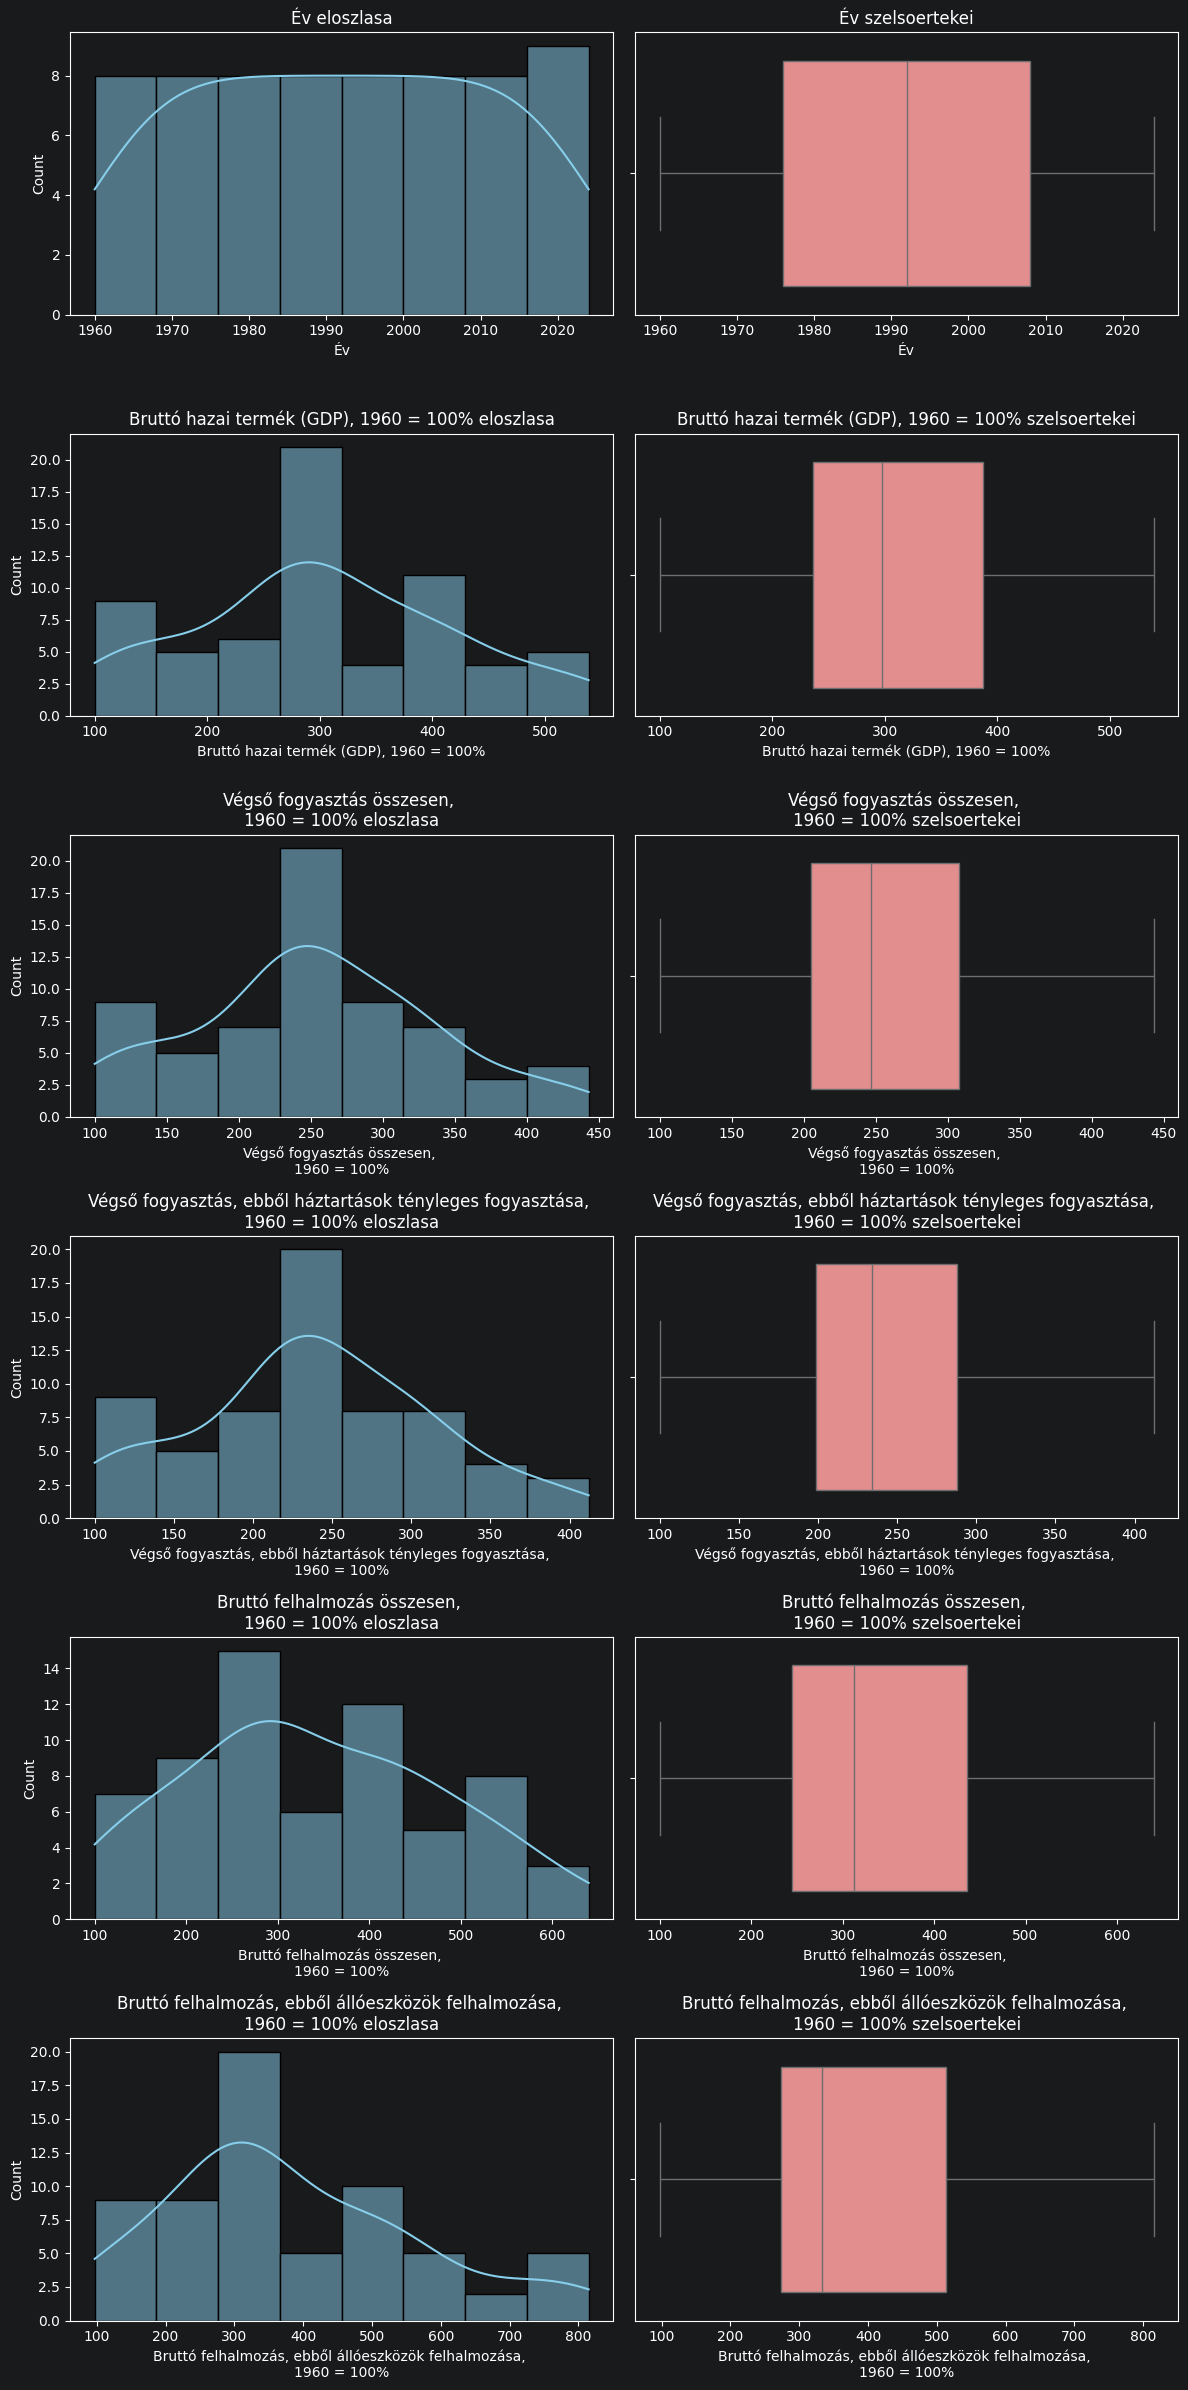

In [2295]:
initial_ana4(gdp_df1, "Bruttó hazai termék")


--- Az egy főre jutó reáljövedelem és fogyasztás ELEMZESE ---


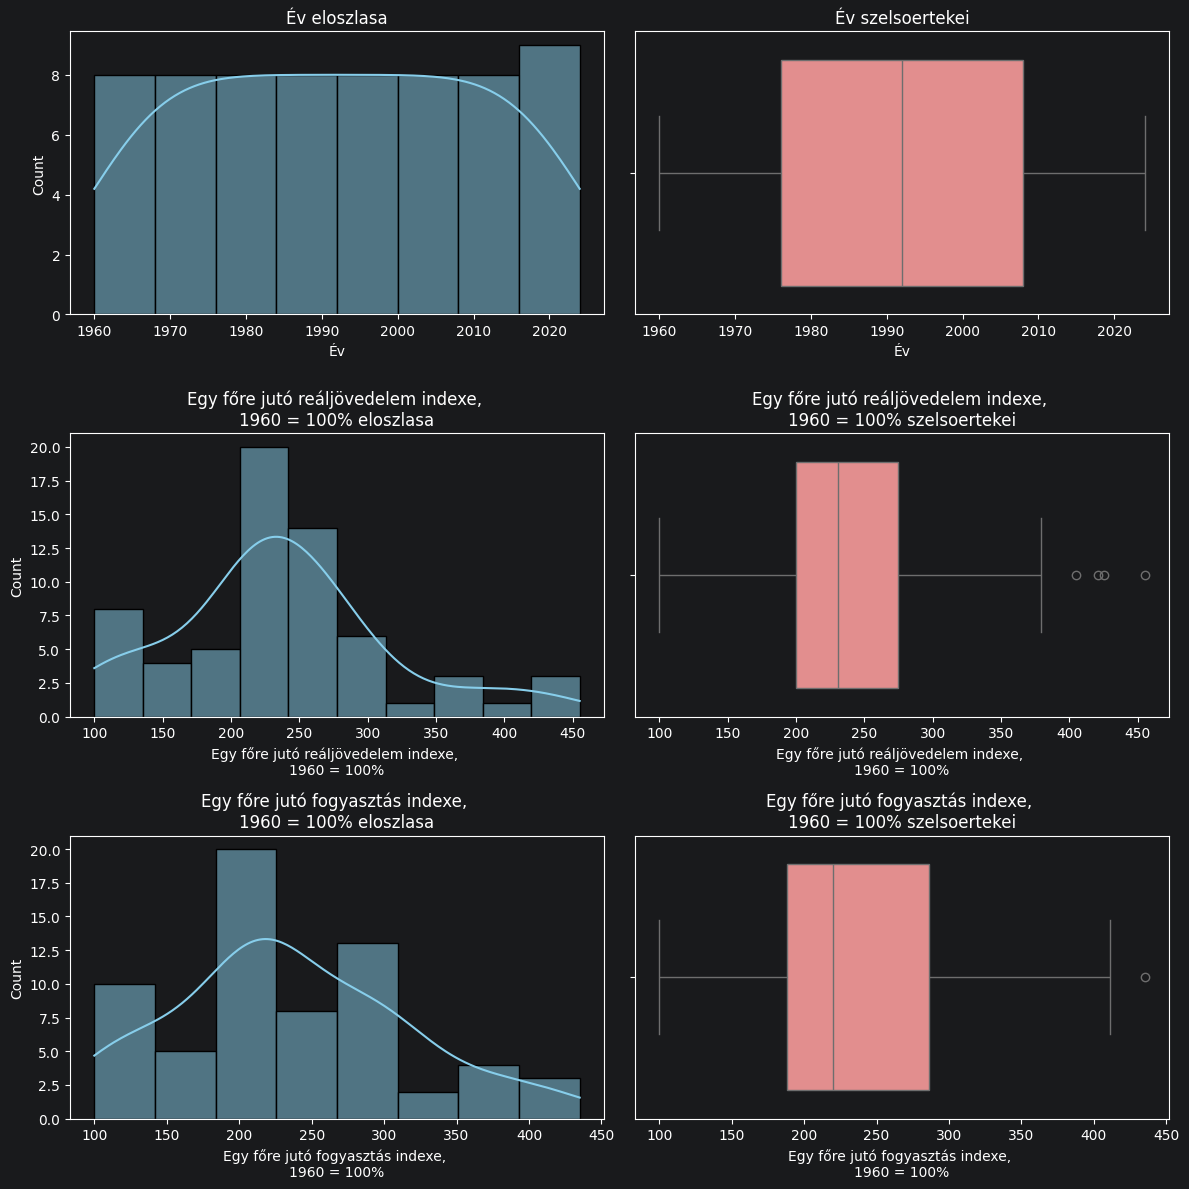

In [2296]:
initial_ana4(gdp_df2, "Az egy főre jutó reáljövedelem és fogyasztás")


In [2297]:
initial_ana4(gdp_df3, "A háztartások fogyasztási kiadásának volumenindexei rendeltetés szerint")


--- A háztartások fogyasztási kiadásának volumenindexei rendeltetés szerint ELEMZESE ---
Nincs numerikus oszlop a histogramokhoz es boxplotokhoz.


--- Az oktatás főbb, hosszú idősoros adatai ELEMZESE ---


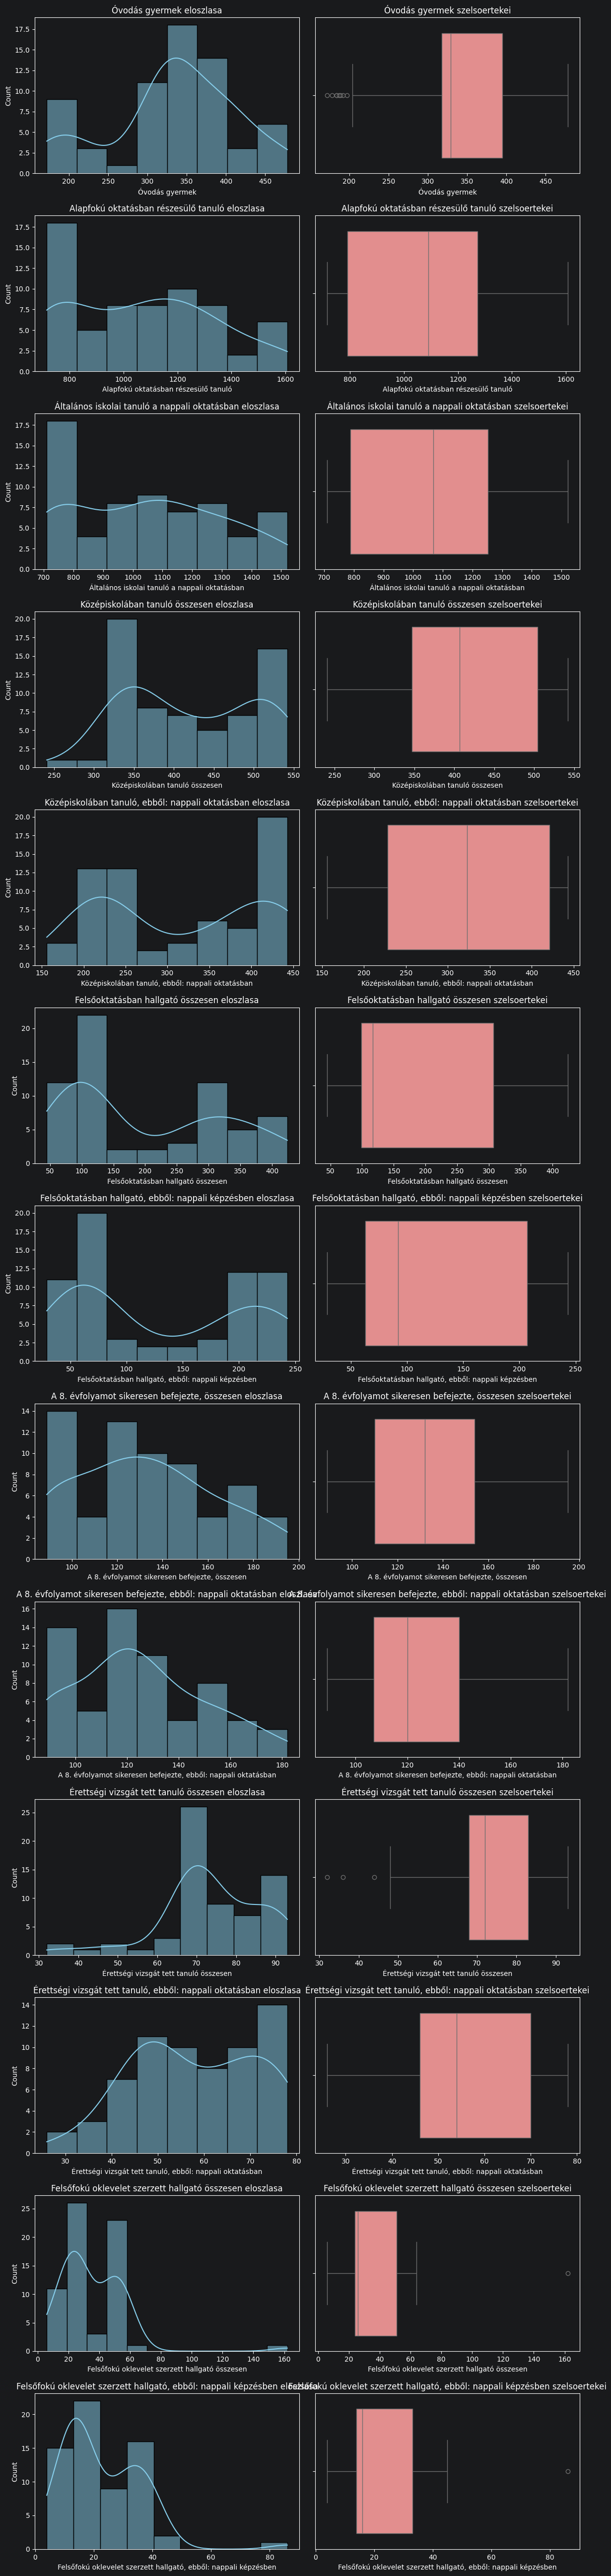

In [2298]:
initial_ana4(okt_df1, "Az oktatás főbb, hosszú idősoros adatai")


--- Felsőfokú alap- és mesterképzés ELEMZESE ---


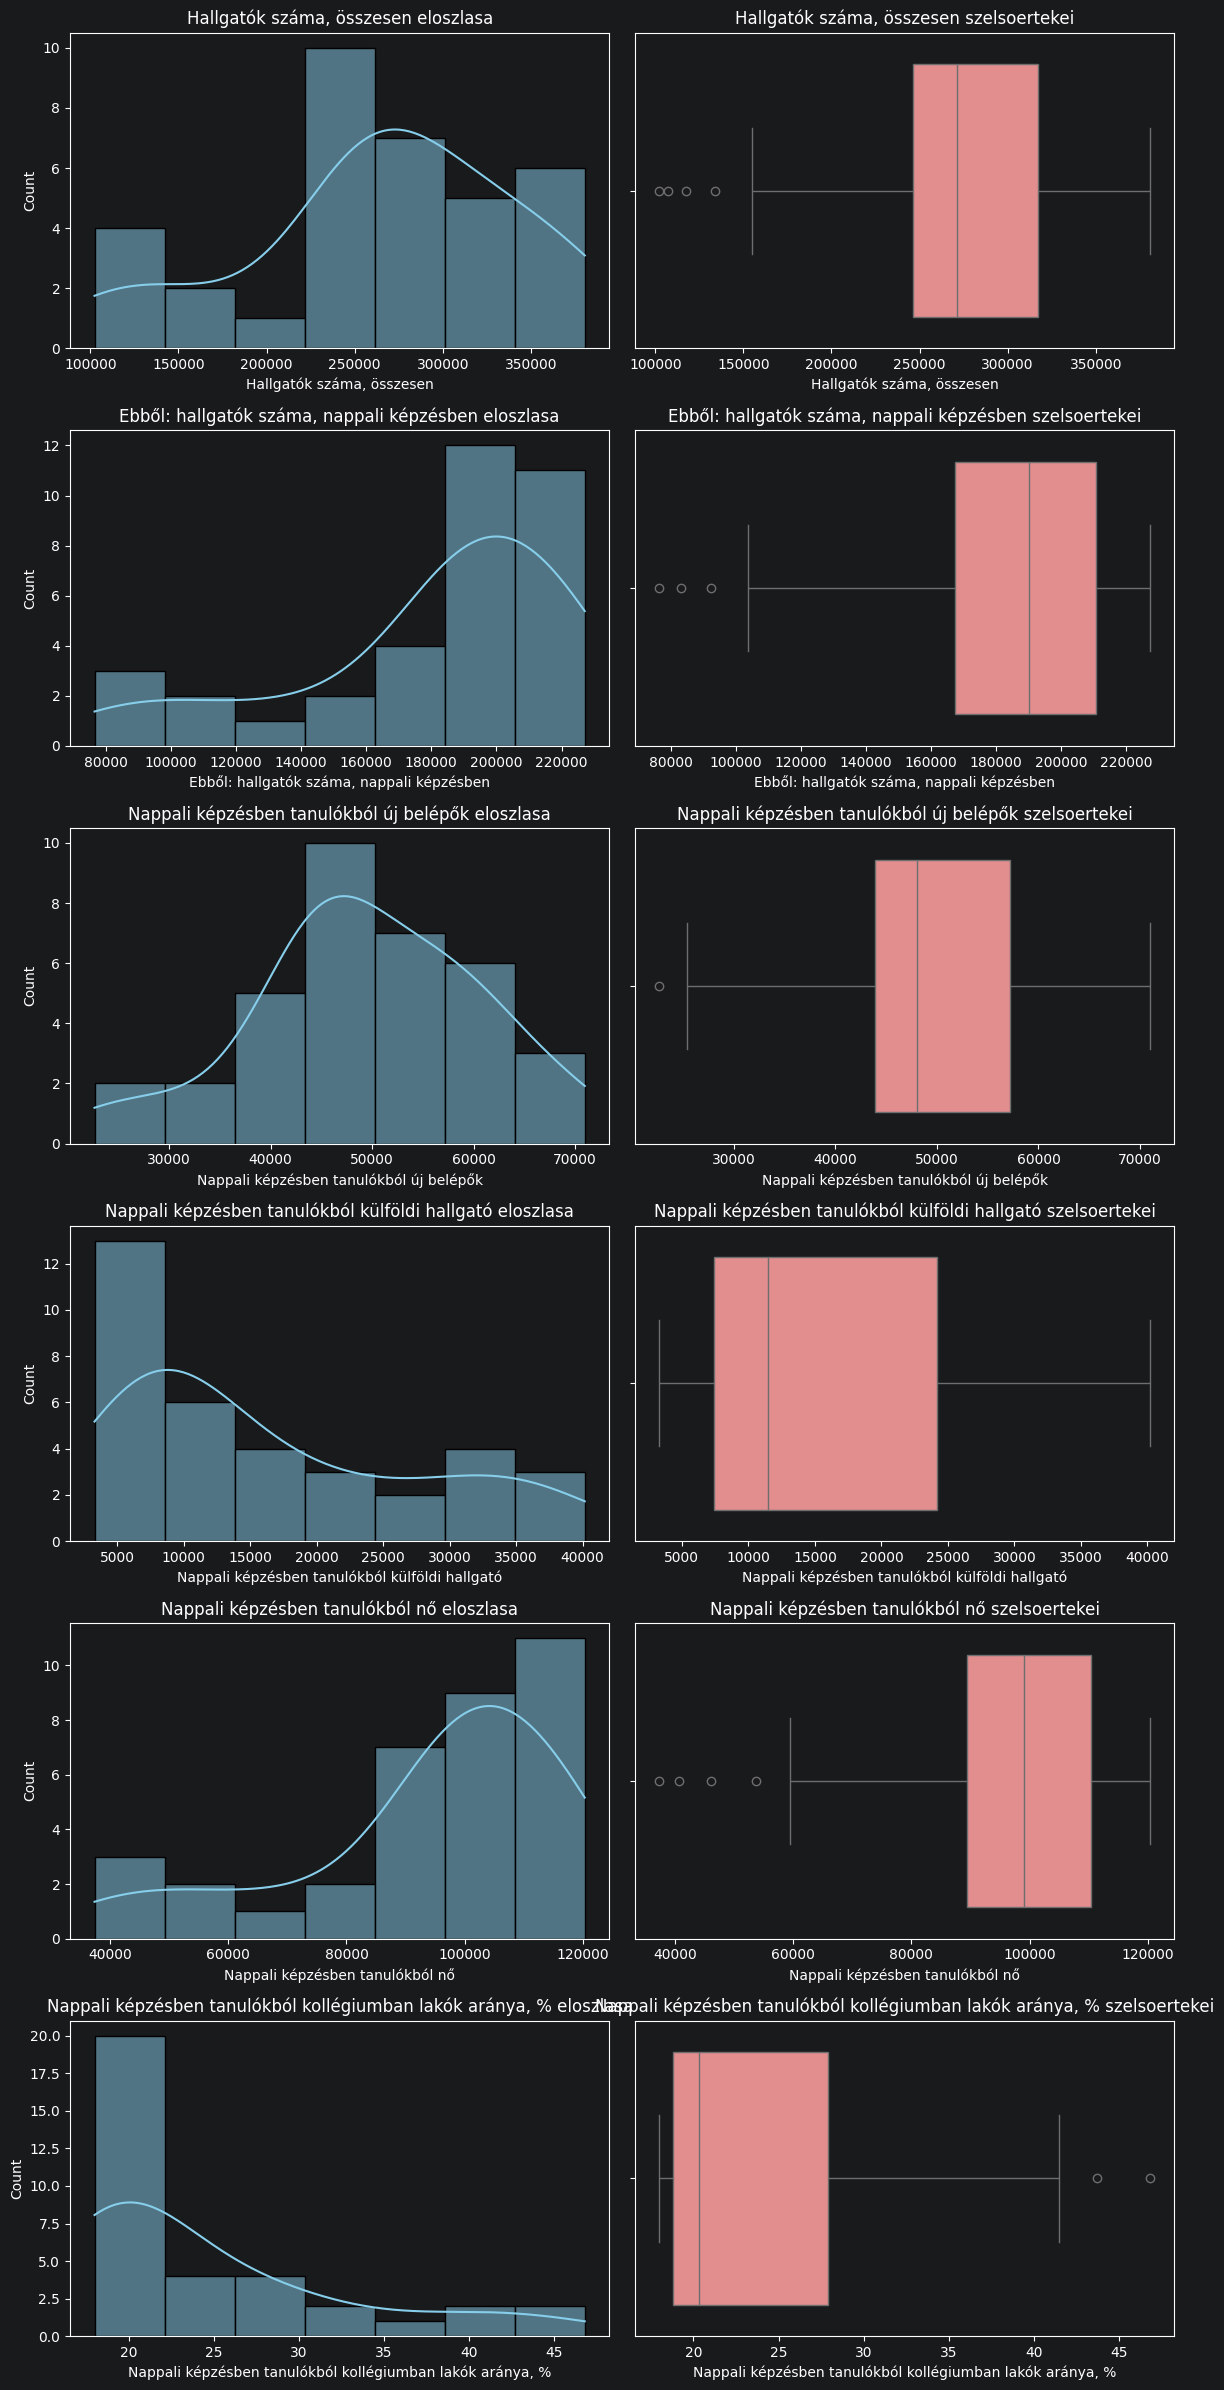

In [2299]:
initial_ana4(okt_df2, "Felsőfokú alap- és mesterképzés")


# Futtatás az egyes adatsorokon - CHECK STEP #5 - Korrelációk

--- Bruttó hazai termék ELEMZESE ---


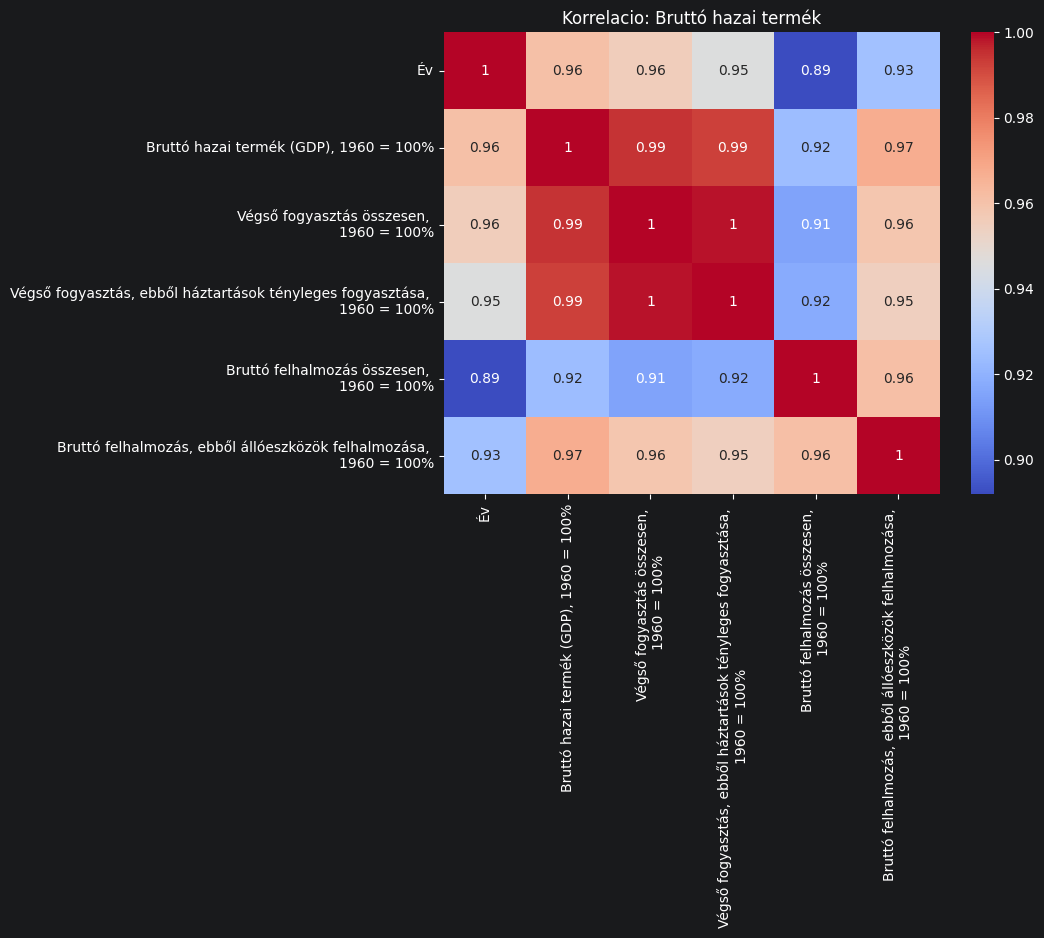

In [2300]:
initial_ana5(gdp_df1, "Bruttó hazai termék")


--- Az egy főre jutó reáljövedelem és fogyasztás ELEMZESE ---


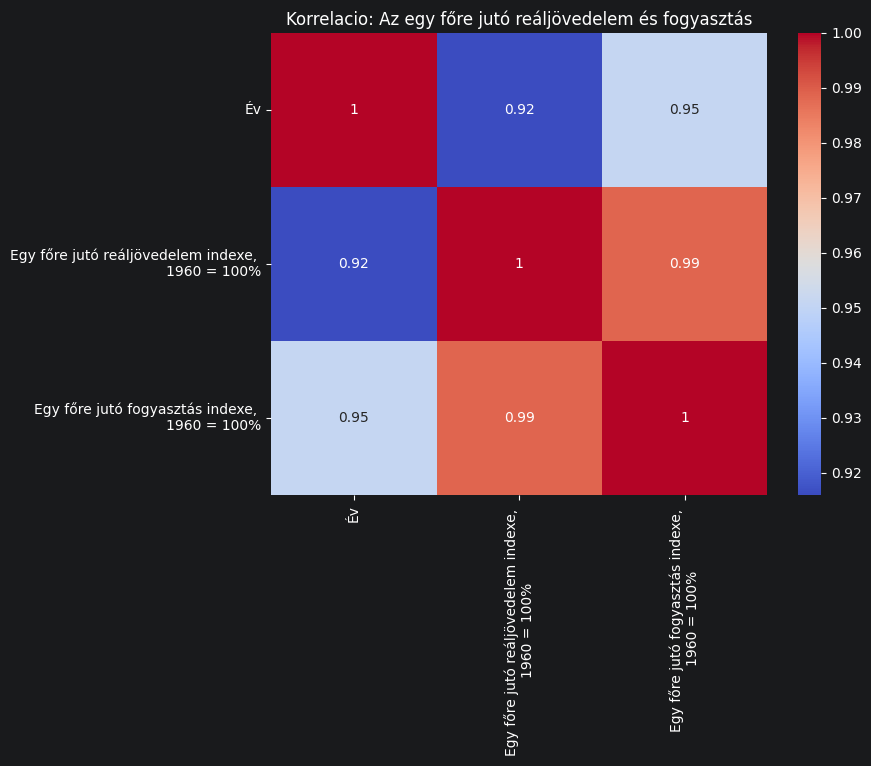

In [2301]:
initial_ana5(gdp_df2, "Az egy főre jutó reáljövedelem és fogyasztás")


--- Fogyasztasi fo kategoriak ELEMZESE ---


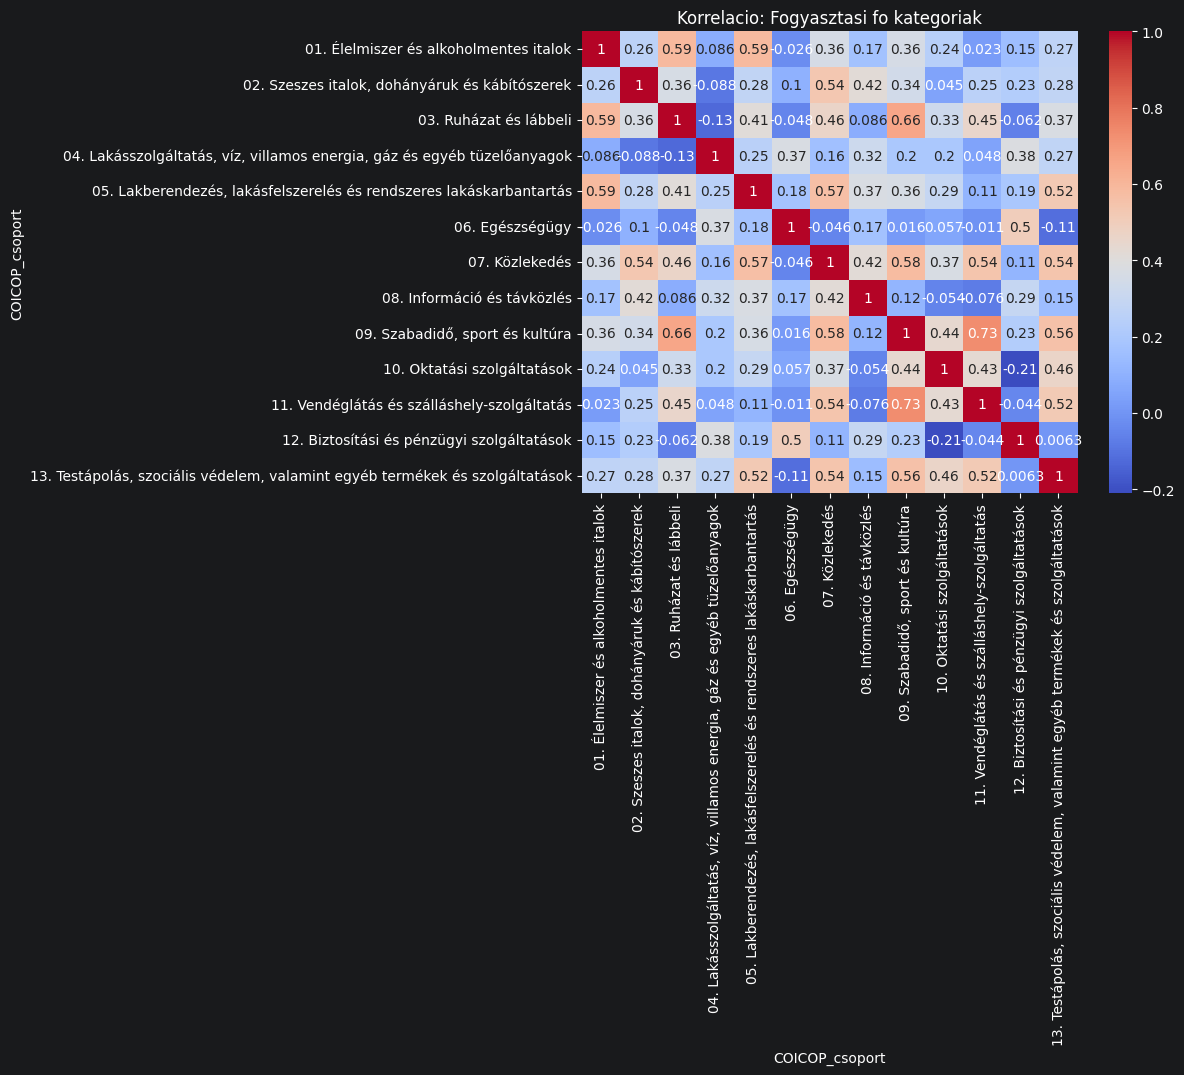

In [2302]:
def clean_coicop_data_final(df):
    df_c = df.copy()

    category_col = df_c.columns[0]
    df_c = df_c.rename(columns={category_col: "COICOP_csoport"})
    df_c = df_c.replace(["x", "..", "...", "-", "--"], np.nan)

    for col in df_c.columns[1:]:
        df_c[col] = pd.to_numeric(df_c[col], errors="coerce")

    value_cols = df_c.columns[1:]
    df_c = df_c.dropna(subset=value_cols, how="all")
    return df_c.reset_index(drop=True)

gdp_df3_clean = clean_coicop_data_final(gdp_df3)

# Keep only the main COICOP categories, for example 01., 02., 03.
main_coicop = gdp_df3_clean[gdp_df3_clean["COICOP_csoport"].astype(str).str.match(r"^\d{2}\.\s", na=False)].copy()

# For correlation, categories should be columns and years should be rows.
coicop_corr_df = main_coicop.set_index("COICOP_csoport").T
coicop_corr_df.index.name = "Ev"
coicop_corr_df = coicop_corr_df.dropna(axis=1, how="all")

initial_ana5(coicop_corr_df, "Fogyasztasi fo kategoriak")


--- Az oktatas fobb, hosszu idosoros adatai ELEMZESE ---


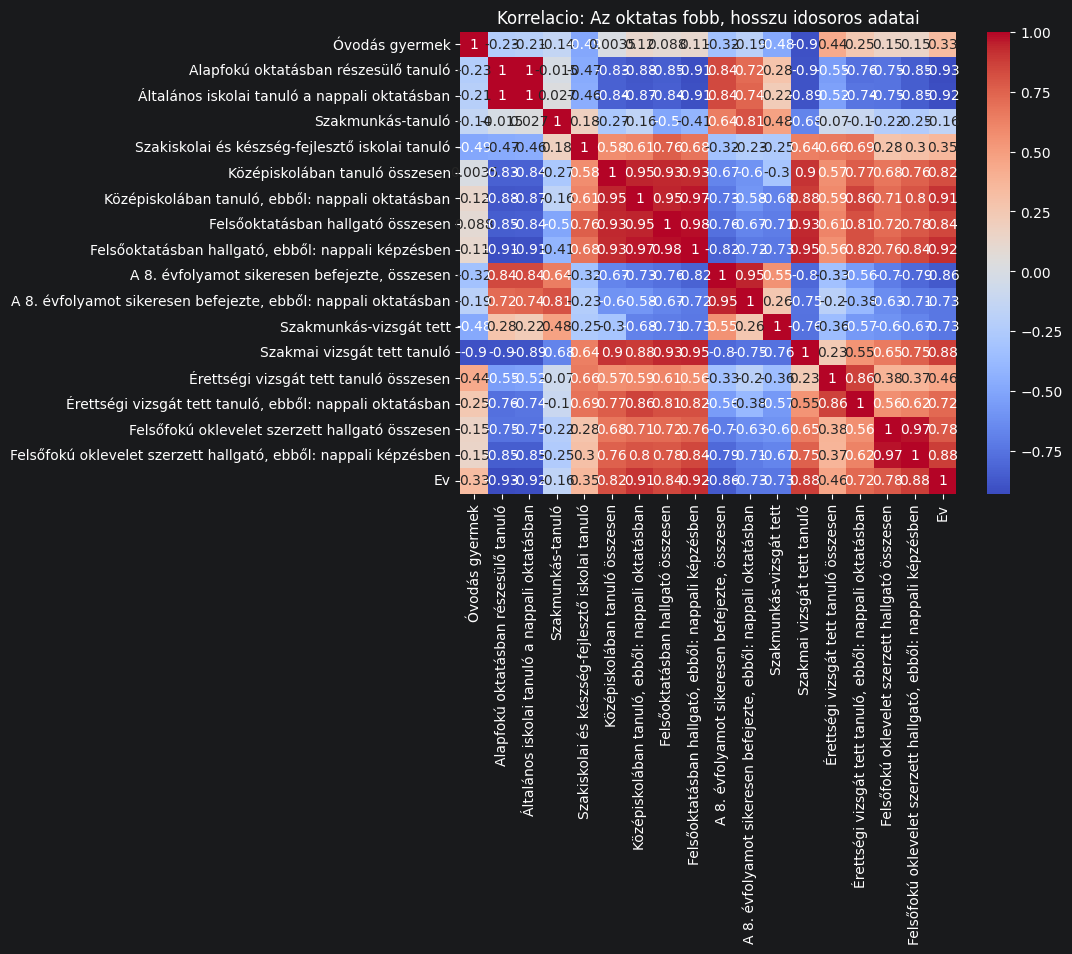

In [2303]:
# 1. Evszam tisztitasa
okt_df1['Ev'] = okt_df1.iloc[:, 0].astype(str).str.extract(r'(\d{4})', expand=False).astype(float)

# 2. Specialis KSH karakterek kezelese az egesz DataFrame-ben
okt_df1 = okt_df1.replace(['-', '--'], np.nan)
okt_df1 = okt_df1.replace(r'\.\.', np.nan, regex=True)
okt_df1 = okt_df1.replace(r'\s+', np.nan, regex=True)

# 3. Ezres elvalasztok eltavolitasa, majd szamma alakitas
for col in okt_df1.columns:
    if col != 'Ev' and okt_df1[col].dtype == 'object':
        okt_df1[col] = okt_df1[col].astype(str).str.replace('\xa0', '', regex=False).str.replace(' ', '', regex=False)
        okt_df1[col] = pd.to_numeric(okt_df1[col], errors='coerce')

# 4. Most mar futtathato az elemzes
initial_ana5(okt_df1, "Az oktatas fobb, hosszu idosoros adatai")


--- Felsofoku alap- es mesterkepzes ELEMZESE ---


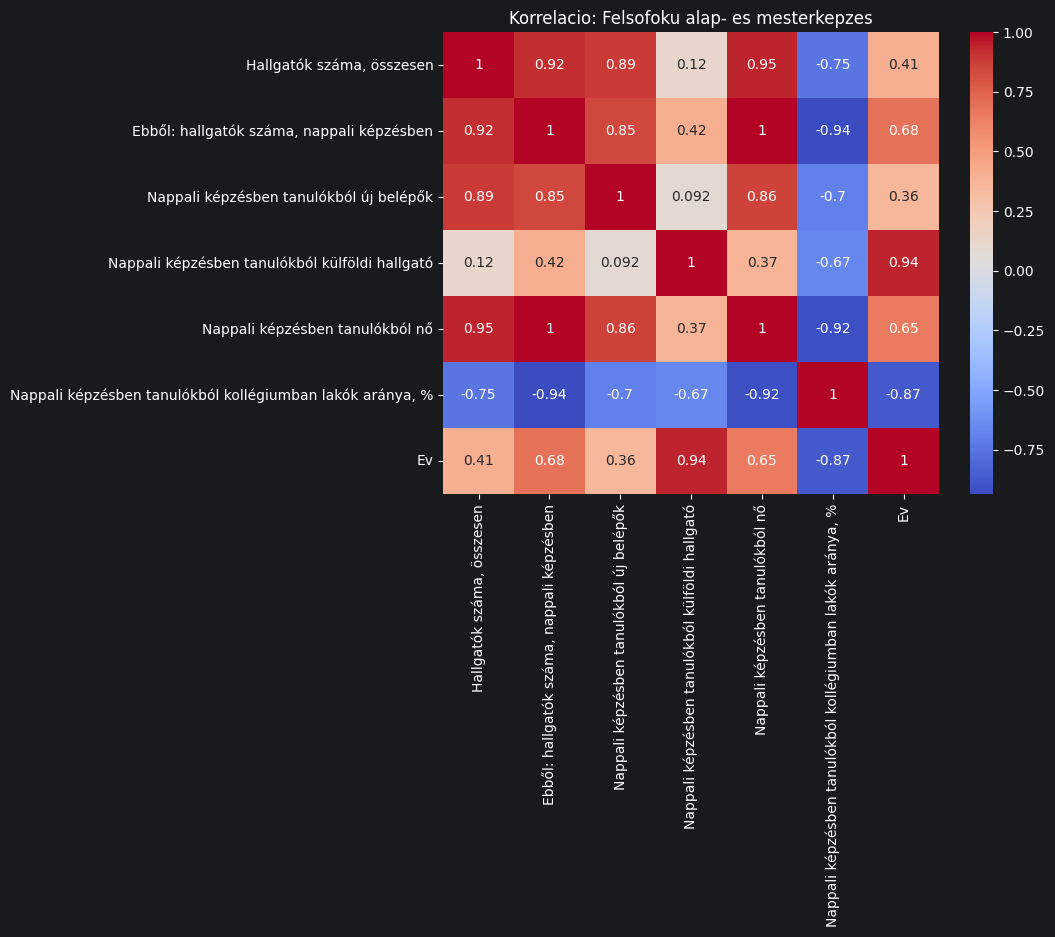

In [2304]:
# 1. Evszam tisztitasa
okt_df2['Ev'] = okt_df2.iloc[:, 0].astype(str).str.extract(r'(\d{4})', expand=False).astype(float)

# 2. Specialis KSH karakterek kezelese az egesz DataFrame-ben
okt_df2 = okt_df2.replace(['-', '--'], np.nan)
okt_df2 = okt_df2.replace(r'\.\.', np.nan, regex=True)
okt_df2 = okt_df2.replace(r'\s+', np.nan, regex=True)

# 3. Ezres elvalasztok eltavolitasa, majd szamma alakitas
for col in okt_df2.columns:
    if col != 'Ev' and okt_df2[col].dtype == 'object':
        okt_df2[col] = okt_df2[col].astype(str).str.replace('\xa0', '', regex=False).str.replace(' ', '', regex=False)
        okt_df2[col] = pd.to_numeric(okt_df2[col], errors='coerce')

# 4. Most mar futtathato az elemzes
initial_ana5(okt_df2, "Felsofoku alap- es mesterkepzes")


Tanulságok:
- Az adatsorokban nem talaltunk duplikalt eveket, igy az idosorok egyertelmuen es rendezetten kezelhetok.
- Az altalunk vizsgalt tablazatokban nem talaltunk hianyzo adatokat, ami megkonnyiti a tovabbi tisztitasi es modellezesi lepeseinket.
- A vegso fogyasztas osszesen, a haztartasok tenyleges fogyasztasa, a realjovedelem es az egy fore juto fogyasztas eros egyuttmozgast mutatnak a GDP-vel, illetve egymassal is, ezert a tovabbi modellben nem tartjuk meg oket. Mivel a cel a GDP(t+5) becslese kifejezetten oktatasi valtozok alapjan, ezekre nem lesz szukseg bemeneti adatkent.
- Az oktatasi adatokban az ovodatol a felsofoku kepzesig tobb valtozo is eros egyuttmozgast mutat, ami arra utal, hogy kozuluk több reszben hasonlo informaciot hordoz. Emiatt ezeket az elso valtozatban meg megtartjuk, de a kesobbi feature-valasztas soran varhatoan nem kerul be mindegyik a vegso modellbe.
- Az oktatási és a pénzügyi adatok is erős korrelációban álnak az idővel (évekkel) ezért itt ovatósnak kell majd értelmezni a kapcsolatot, mert nem bizonyitható, hogy egymással is közvetlen a kapcsolat.

# Adatok tisztitasa


- Adattisztitas utan egy kozos modellezesi tablat hozunk letre.
- A bemeneti valtozok az adott ev oktatasi adatai, a celvaltozo pedig az 10 evvel kesobbi GDP.
- Az idosoros jelleg miatt az adatokat idorendben osztjuk fel: 70% train, 15% validation, 15% test.


In [2305]:
# A GDP tablaban csak az evet es a GDP oszlopot tartjuk meg.
gdp_target = gdp_df1.iloc[:, [0, 1]].copy()
gdp_target.columns = ["Ev", "GDP"]

# Szam tipusu ev es GDP
gdp_target["Ev"] = pd.to_numeric(gdp_target["Ev"], errors="coerce")
gdp_target["GDP"] = pd.to_numeric(gdp_target["GDP"], errors="coerce")

# Letrehozzuk az 10 evvel kesobbi GDP targetet
gdp_target["Ev"] = gdp_target["Ev"].astype(int)
gdp_target["GDP_t_plus_10"] = gdp_target["GDP"].shift(-10)

display(gdp_target.head())

,Ev,GDP,GDP_t_plus_10
0,1960,100,168.0
1,1961,105,179.0
2,1962,111,190.0
3,1963,117,203.0
4,1964,123,215.0


In [2306]:
# Az oktatasi tablaban letrehozzuk az ev oszlopot a tanev kezdoeve alapjan.
okt_clean = okt_df1.copy()

okt_clean["Ev"] = (
    okt_clean.iloc[:, 0]
    .astype(str)
    .str.extract(r"(\d{4})", expand=False)
)

okt_clean["Ev"] = pd.to_numeric(okt_clean["Ev"], errors="coerce")
okt_clean = okt_clean.dropna(subset=["Ev"]).copy()
okt_clean["Ev"] = okt_clean["Ev"].astype(int)

display(okt_clean.head())


,Év,Óvodás gyermek,Alapfokú oktatásban részesülő tanuló,Általános iskolai tanuló a nappali oktatásban,Szakmunkás-tanuló,Szakiskolai és készség-fejlesztő iskolai tanuló,Középiskolában tanuló összesen,"Középiskolában tanuló, ebből: nappali oktatásban",Felsőoktatásban hallgató összesen,"Felsőoktatásban hallgató, ebből: nappali képzésben","A 8. évfolyamot sikeresen befejezte, összesen","A 8. évfolyamot sikeresen befejezte, ebből: nappali oktatásban",Szakmunkás-vizsgát tett,Szakmai vizsgát tett tanuló,Érettségi vizsgát tett tanuló összesen,"Érettségi vizsgát tett tanuló, ebből: nappali oktatásban",Felsőfokú oklevelet szerzett hallgató összesen,"Felsőfokú oklevelet szerzett hallgató, ebből: nappali képzésben",Ev
0,1960/1961,184,1509,1433,125.0,NaN,241,156,45,29,120,107,60.0,NaN,32,26,6,4,1960
1,1961/1962,172,1555,1494,135.0,NaN,284,171,53,35,156,127,65.0,NaN,36,31,6,4,1961
2,1962/1963,178,1605,1521,144.0,NaN,334,187,67,40,171,140,71.0,NaN,44,36,7,5,1962
3,1963/1964,184,1607,1512,151.0,NaN,385,211,82,45,179,148,81.0,NaN,50,36,10,7,1963
4,1964/1965,187,1561,1486,164.0,NaN,417,231,92,49,195,154,76.0,NaN,57,38,11,8,1964


In [2307]:
# A regi, szoveges "Év" elhagyjuk, mert mar letrehoztuk a tiszta Ev oszlopot.
okt_clean = okt_clean.drop(columns=[okt_clean.columns[0]])

# Az Ev oszlopon kivul minden oktatasi valtozot numerikussa alakitunk.
for col in okt_clean.columns:
    if col != "Ev":
        okt_clean[col] = (
            okt_clean[col]
            .astype(str)
            .str.replace("\xa0", "", regex=False)
            .str.replace(" ", "", regex=False)
            .str.replace(",", ".", regex=False)
        )
        okt_clean[col] = pd.to_numeric(okt_clean[col], errors="coerce")

display(okt_clean.head())


,Óvodás gyermek,Alapfokú oktatásban részesülő tanuló,Általános iskolai tanuló a nappali oktatásban,Szakmunkás-tanuló,Szakiskolai és készség-fejlesztő iskolai tanuló,Középiskolában tanuló összesen,"Középiskolában tanuló, ebből: nappali oktatásban",Felsőoktatásban hallgató összesen,"Felsőoktatásban hallgató, ebből: nappali képzésben","A 8. évfolyamot sikeresen befejezte, összesen","A 8. évfolyamot sikeresen befejezte, ebből: nappali oktatásban",Szakmunkás-vizsgát tett,Szakmai vizsgát tett tanuló,Érettségi vizsgát tett tanuló összesen,"Érettségi vizsgát tett tanuló, ebből: nappali oktatásban",Felsőfokú oklevelet szerzett hallgató összesen,"Felsőfokú oklevelet szerzett hallgató, ebből: nappali képzésben",Ev
0,184,1509,1433,125.0,NaN,241,156,45,29,120,107,60.0,NaN,32,26,6,4,1960
1,172,1555,1494,135.0,NaN,284,171,53,35,156,127,65.0,NaN,36,31,6,4,1961
2,178,1605,1521,144.0,NaN,334,187,67,40,171,140,71.0,NaN,44,36,7,5,1962
3,184,1607,1512,151.0,NaN,385,211,82,45,179,148,81.0,NaN,50,36,10,7,1963
4,187,1561,1486,164.0,NaN,417,231,92,49,195,154,76.0,NaN,57,38,11,8,1964


In [2308]:
# Az oktatasi adatokhoz hozzakapcsoljuk az 10 evvel kesobbi GDP-t.
model_df = okt_clean.merge(
    gdp_target[["Ev", "GDP_t_plus_10"]],
    on="Ev",
    how="left"
)

# Csak azok a sorok maradnak, ahol van 10 evvel kesobbi GDP.
model_df = model_df.dropna(subset=["GDP_t_plus_10"]).copy()

display(model_df.head())
print("A kozos modellezesi tabla merete:", model_df.shape)


,Óvodás gyermek,Alapfokú oktatásban részesülő tanuló,Általános iskolai tanuló a nappali oktatásban,Szakmunkás-tanuló,Szakiskolai és készség-fejlesztő iskolai tanuló,Középiskolában tanuló összesen,"Középiskolában tanuló, ebből: nappali oktatásban",Felsőoktatásban hallgató összesen,"Felsőoktatásban hallgató, ebből: nappali képzésben","A 8. évfolyamot sikeresen befejezte, összesen","A 8. évfolyamot sikeresen befejezte, ebből: nappali oktatásban",Szakmunkás-vizsgát tett,Szakmai vizsgát tett tanuló,Érettségi vizsgát tett tanuló összesen,"Érettségi vizsgát tett tanuló, ebből: nappali oktatásban",Felsőfokú oklevelet szerzett hallgató összesen,"Felsőfokú oklevelet szerzett hallgató, ebből: nappali képzésben",Ev,GDP_t_plus_10
0,184,1509,1433,125.0,NaN,241,156,45,29,120,107,60.0,NaN,32,26,6,4,1960,168.0
1,172,1555,1494,135.0,NaN,284,171,53,35,156,127,65.0,NaN,36,31,6,4,1961,179.0
2,178,1605,1521,144.0,NaN,334,187,67,40,171,140,71.0,NaN,44,36,7,5,1962,190.0
3,184,1607,1512,151.0,NaN,385,211,82,45,179,148,81.0,NaN,50,36,10,7,1963,203.0
4,187,1561,1486,164.0,NaN,417,231,92,49,195,154,76.0,NaN,57,38,11,8,1964,215.0


A kozos modellezesi tabla merete: (55, 19)


In [2309]:
# Azokat a valtozokat elhagyjuk a kozos modellezesi tablabol, ahol sok a hianyzo adat.
model_df = model_df.drop(columns=[
    "Szakiskolai és készség-fejlesztő iskolai tanuló",
    "Szakmai vizsgát tett tanuló",
    "Szakmunkás-tanuló",
    "Szakmunkás-vizsgát tett"
])

print("Hianyzo adatok a kozos modellezesi tablaban:")
print(model_df.isna().sum())

print("A kozos modellezesi tabla merete:", model_df.shape)


Hianyzo adatok a kozos modellezesi tablaban:
Óvodás gyermek                                                     0
Alapfokú oktatásban részesülő tanuló                               0
Általános iskolai tanuló a nappali oktatásban                      0
Középiskolában tanuló összesen                                     0
Középiskolában tanuló, ebből: nappali oktatásban                   0
Felsőoktatásban hallgató összesen                                  0
Felsőoktatásban hallgató, ebből: nappali képzésben                 0
A 8. évfolyamot sikeresen befejezte, összesen                      0
A 8. évfolyamot sikeresen befejezte, ebből: nappali oktatásban     0
Érettségi vizsgát tett tanuló összesen                             0
Érettségi vizsgát tett tanuló, ebből: nappali oktatásban           0
Felsőfokú oklevelet szerzett hallgató összesen                     0
Felsőfokú oklevelet szerzett hallgató, ebből: nappali képzésben    0
Ev                                                        

In [2310]:
# Idorendbe rendezzuk a kozos modellezesi tablat.
model_df = model_df.sort_values("Ev").reset_index(drop=True)

display(model_df[["Ev", "GDP_t_plus_10"]].head())
display(model_df[["Ev", "GDP_t_plus_10"]].tail())

,Ev,GDP_t_plus_10
0,1960,168.0
1,1961,179.0
2,1962,190.0
3,1963,203.0
4,1964,215.0


,Ev,GDP_t_plus_10
50,2010,483.0
51,2011,518.0
52,2012,539.0
53,2013,535.0
54,2014,539.0


In [2311]:
# A kozos modellezesi tablat train, validation es test halmazokra bontjuk.
n = len(model_df)

train_end = int(n * 0.70)
val_end = int(n * 0.85)

train_df = model_df.iloc[:train_end].copy()
val_df = model_df.iloc[train_end:val_end].copy()
test_df = model_df.iloc[val_end:].copy()

print("train:", train_df.shape)
print("validation:", val_df.shape)
print("test:", test_df.shape)


train: (38, 15)
validation: (8, 15)
test: (9, 15)


# Data Exploration

In [2312]:
model_df.describe()

,Óvodás gyermek,Alapfokú oktatásban részesülő tanuló,Általános iskolai tanuló a nappali oktatásban,Középiskolában tanuló összesen,"Középiskolában tanuló, ebből: nappali oktatásban",Felsőoktatásban hallgató összesen,"Felsőoktatásban hallgató, ebből: nappali képzésben","A 8. évfolyamot sikeresen befejezte, összesen","A 8. évfolyamot sikeresen befejezte, ebből: nappali oktatásban",Érettségi vizsgát tett tanuló összesen,"Érettségi vizsgát tett tanuló, ebből: nappali oktatásban",Felsőfokú oklevelet szerzett hallgató összesen,"Felsőfokú oklevelet szerzett hallgató, ebből: nappali képzésben",Ev,GDP_t_plus_10
count,55.000000,55.000000,55.000000,55.000000,55.000000,55.000000,55.000000,55.000000,55.000000,55.000000,55.000000,55.000000,55.000000,55.00000,55.000000
mean,334.909091,1131.690909,1110.618182,402.345455,297.600000,183.490909,115.272727,140.236364,130.800000,74.418182,57.327273,30.600000,19.254545,1987.00000,336.909091
std,86.348834,242.160635,225.882671,78.444653,95.202824,124.913877,74.588117,27.278375,22.088542,13.543744,14.481220,14.674998,9.739606,16.02082,95.607468
min,172.000000,745.000000,743.000000,241.000000,156.000000,45.000000,29.000000,90.000000,89.000000,32.000000,26.000000,6.000000,4.000000,1960.00000,168.000000
25%,306.000000,954.000000,951.000000,339.500000,218.500000,98.500000,62.500000,119.000000,117.000000,68.000000,46.000000,22.500000,12.500000,1973.50000,271.000000
50%,340.000000,1141.000000,1106.000000,376.000000,240.000000,106.000000,67.000000,138.000000,126.000000,74.000000,53.000000,25.000000,15.000000,1987.00000,312.000000
75%,395.500000,1305.500000,1291.000000,468.000000,388.000000,313.500000,188.500000,157.000000,148.000000,86.500000,71.000000,47.000000,29.000000,2000.50000,398.000000
max,478.000000,1607.000000,1521.000000,534.000000,443.000000,424.000000,243.000000,195.000000,182.000000,93.000000,78.000000,57.000000,39.000000,2014.00000,539.000000


- A táblának 60 sora van és enm hiányzik adat.
- Az adatokat érdemes lehet majd skálázni, mert nagyon különböző tartományban mozognak

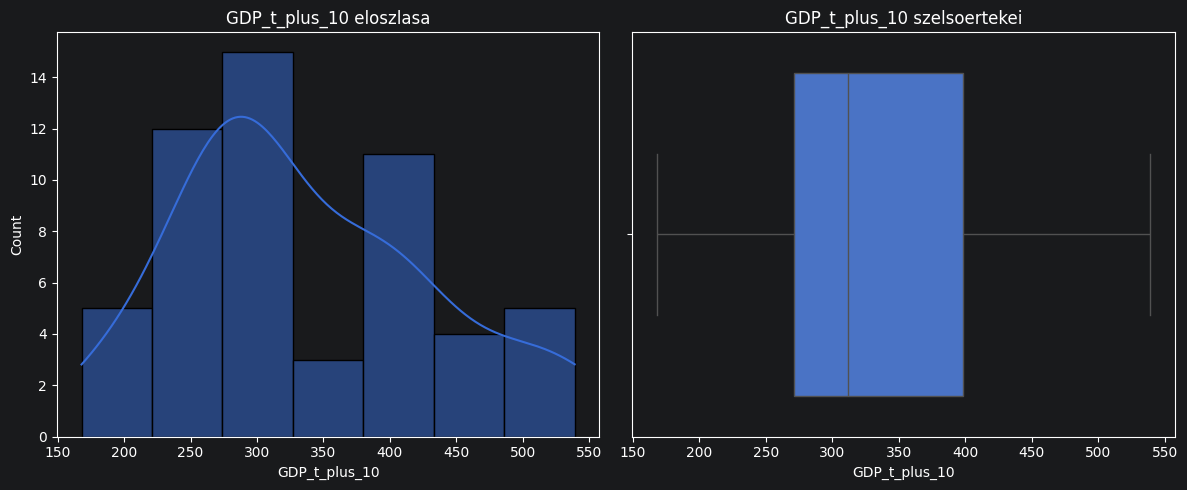

In [2313]:
# Megnezzuk a celvaltozo, vagyis a GDP_t_plus_10 eloszlasat es szelsoertekeit.
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.histplot(model_df["GDP_t_plus_10"], kde=True)
plt.title("GDP_t_plus_10 eloszlasa")

plt.subplot(1, 2, 2)
sns.boxplot(x=model_df["GDP_t_plus_10"])
plt.title("GDP_t_plus_10 szelsoertekei")

plt.tight_layout()
plt.show()

A target eloszlasa alapjan a GDP_t_plus_10 nem teljesen egyenletes mintazatot mutat, ami arra utal, hogy az idobeli valtozas nem minden idoszakban azonos merteku. Ezt azonban pontosabban egy idosoros abra alapjan lehet megitelni.

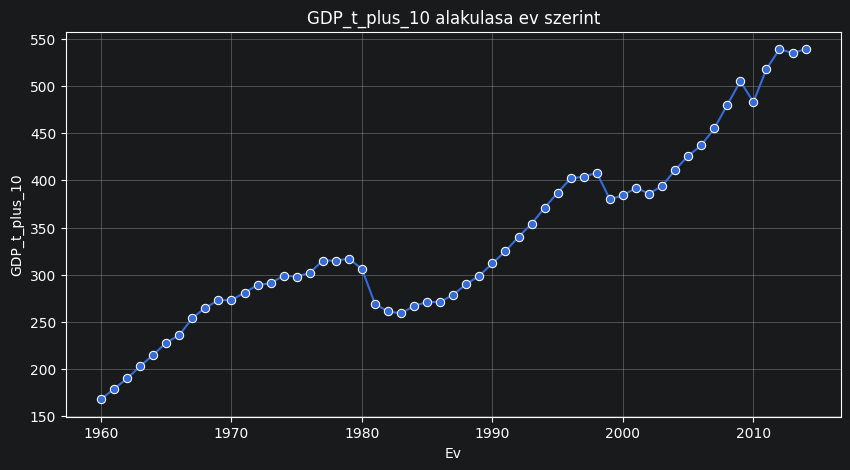

In [2314]:
# Megnezzuk, hogyan alakul a GDP_t_plus_10 az evek menten.
plt.figure(figsize=(10, 5))
sns.lineplot(data=model_df, x="Ev", y="GDP_t_plus_10", marker="o")
plt.title("GDP_t_plus_10 alakulasa ev szerint")
plt.xlabel("Ev")
plt.ylabel("GDP_t_plus_10")
plt.grid(True)
plt.show()


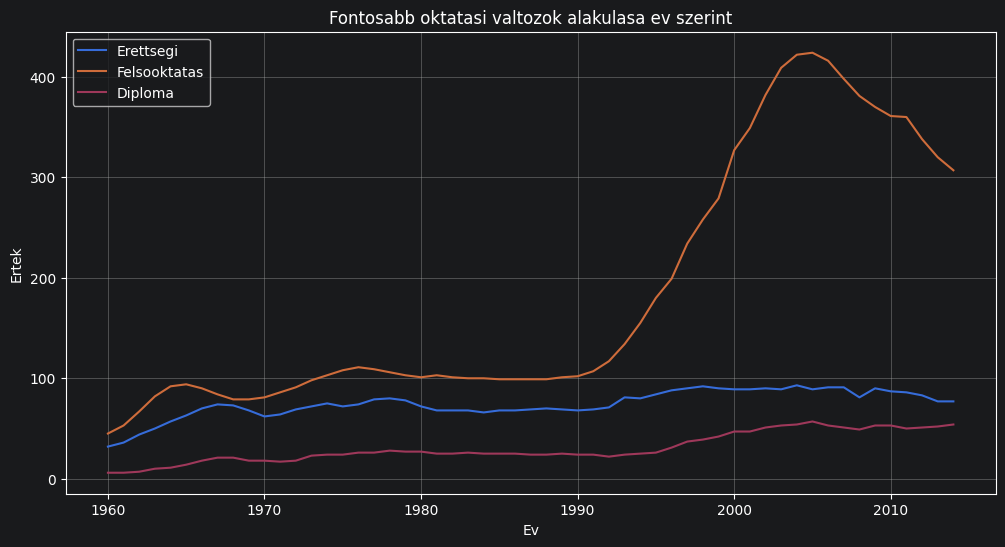

In [2315]:
# Néhany fontosabb oktatasi valtozo alakulasa ev szerint.
plt.figure(figsize=(12, 6))

sns.lineplot(data=model_df, x="Ev", y="Érettségi vizsgát tett tanuló összesen", label="Erettsegi")
sns.lineplot(data=model_df, x="Ev", y="Felsőoktatásban hallgató összesen", label="Felsooktatas")
sns.lineplot(data=model_df, x="Ev", y="Felsőfokú oklevelet szerzett hallgató összesen", label="Diploma")

plt.title("Fontosabb oktatasi valtozok alakulasa ev szerint")
plt.xlabel("Ev")
plt.ylabel("Ertek")
plt.grid(True)
plt.legend()
plt.show()


Az idosoros abrak alapjan a megvizsgalt oktatasi valtozok eseteben ugyan megfigyelheto egy altalanos trend, de alakjuk nem egyezik meg teljesen a GDP_t_plus_10 alakulásával. Ez arra utal, hogy kapcsolatukat nem kizarolag az idobeli egyuttmozgas magyarazhatja.

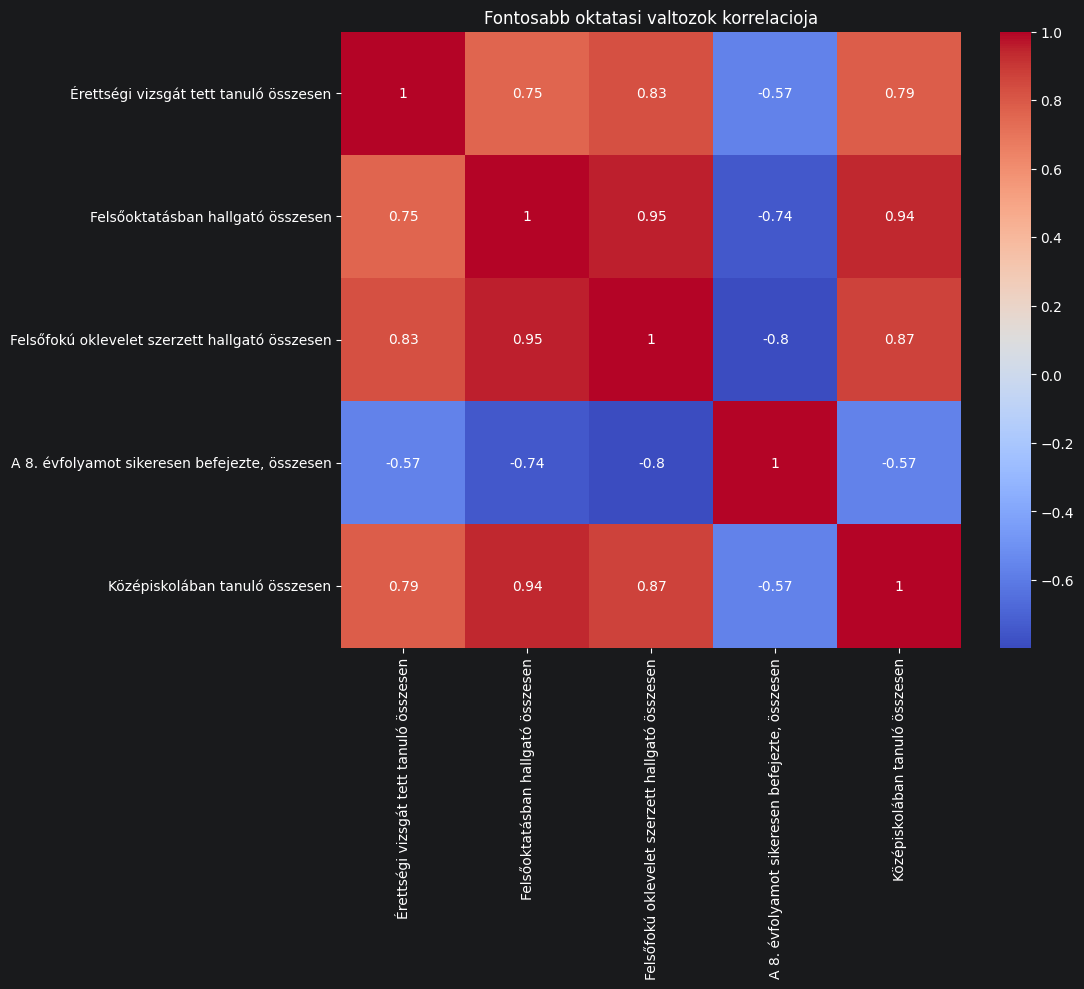

In [2316]:
# Megnezzuk, hogyan fuggnek ossze egymassal a fontosabb oktatasi valtozok.
okt_subset = model_df[[
    "Érettségi vizsgát tett tanuló összesen",
    "Felsőoktatásban hallgató összesen",
    "Felsőfokú oklevelet szerzett hallgató összesen",
    "A 8. évfolyamot sikeresen befejezte, összesen",
    "Középiskolában tanuló összesen"
]]

plt.figure(figsize=(10, 8))
sns.heatmap(okt_subset.corr(), annot=True, cmap="coolwarm")
plt.title("Fontosabb oktatasi valtozok korrelacioja")
plt.show()


- A fontosabb oktatasi valtozok korrelacioja alapjan a `kozepiskolaban tanulo`, a `felsooktatasban hallgato` es a `felsofoku oklevelet szerzett hallgato` valtozok eros egyuttmozgast mutatnak, ami arra utal, hogy reszben hasonlo informaciot hordoznak. Az `erettsegi` kozepesen eros kapcsolatban all ezekkel, mig a `8. evfolyamot sikeresen befejezte` valtozo eltero mintazatot mutat.

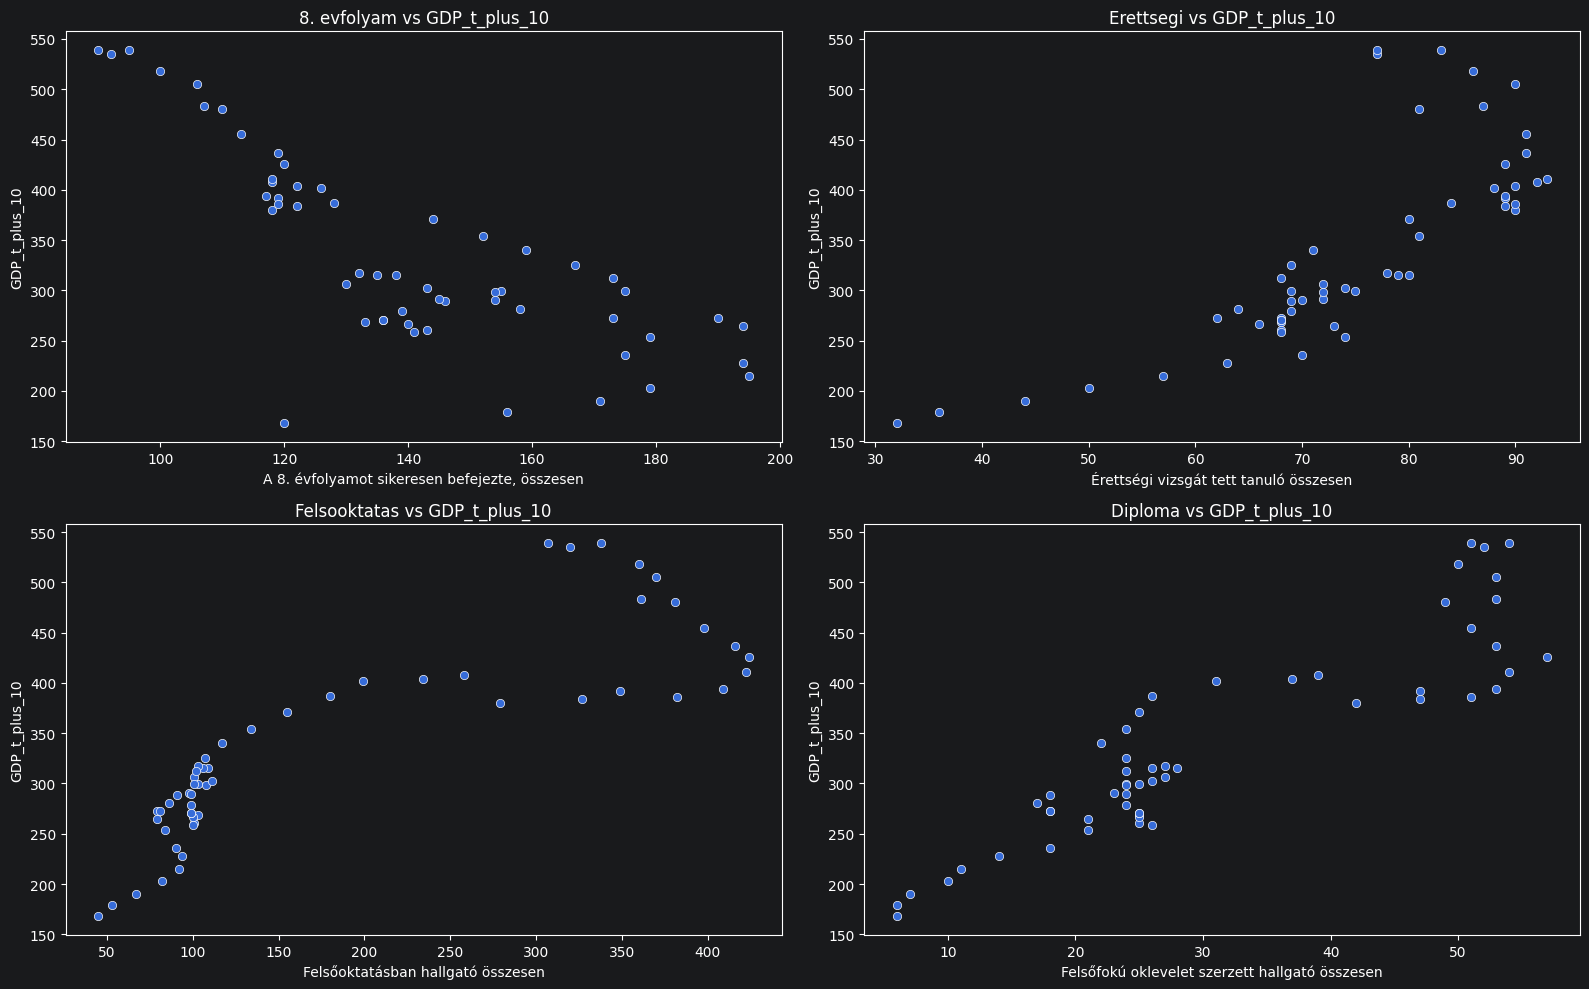

In [2317]:
# Megnezzuk, hogy a fontosabb oktatasi valtozok hogyan fuggnek ossze a GDP_t_plus_10-tel.
plt.figure(figsize=(16, 10))

plt.subplot(2, 2, 1)
sns.scatterplot(data=model_df, x="A 8. évfolyamot sikeresen befejezte, összesen", y="GDP_t_plus_10")
plt.title("8. evfolyam vs GDP_t_plus_10")

plt.subplot(2, 2, 2)
sns.scatterplot(data=model_df, x="Érettségi vizsgát tett tanuló összesen", y="GDP_t_plus_10")
plt.title("Erettsegi vs GDP_t_plus_10")

plt.subplot(2, 2, 3)
sns.scatterplot(data=model_df, x="Felsőoktatásban hallgató összesen", y="GDP_t_plus_10")
plt.title("Felsooktatas vs GDP_t_plus_10")

plt.subplot(2, 2, 4)
sns.scatterplot(data=model_df, x="Felsőfokú oklevelet szerzett hallgató összesen", y="GDP_t_plus_10")
plt.title("Diploma vs GDP_t_plus_10")

plt.tight_layout()
plt.show()



- A diplomat megszerzok szama korrelalni latszik az 10 evvel kesobbi GDP 10 evvel kesobbi erteke. Meg a 8 altalanost teljesitok szama egy negativ korrelaciot mutat.(ez valoszinuleg az idovel fugg ossze)

# Feature engineering

In [2318]:
# Elso korben minden bent maradt oktatasi valtozot megtartunk feature-kent.
feature_df = model_df.copy()

display(feature_df.head())
print("A feature tabla merete:", feature_df.shape)
print("Oszlopok:")
print(feature_df.columns.tolist())


,Óvodás gyermek,Alapfokú oktatásban részesülő tanuló,Általános iskolai tanuló a nappali oktatásban,Középiskolában tanuló összesen,"Középiskolában tanuló, ebből: nappali oktatásban",Felsőoktatásban hallgató összesen,"Felsőoktatásban hallgató, ebből: nappali képzésben","A 8. évfolyamot sikeresen befejezte, összesen","A 8. évfolyamot sikeresen befejezte, ebből: nappali oktatásban",Érettségi vizsgát tett tanuló összesen,"Érettségi vizsgát tett tanuló, ebből: nappali oktatásban",Felsőfokú oklevelet szerzett hallgató összesen,"Felsőfokú oklevelet szerzett hallgató, ebből: nappali képzésben",Ev,GDP_t_plus_10
0,184,1509,1433,241,156,45,29,120,107,32,26,6,4,1960,168.0
1,172,1555,1494,284,171,53,35,156,127,36,31,6,4,1961,179.0
2,178,1605,1521,334,187,67,40,171,140,44,36,7,5,1962,190.0
3,184,1607,1512,385,211,82,45,179,148,50,36,10,7,1963,203.0
4,187,1561,1486,417,231,92,49,195,154,57,38,11,8,1964,215.0


A feature tabla merete: (55, 15)
Oszlopok:
['Óvodás gyermek', 'Alapfokú oktatásban részesülő tanuló', 'Általános iskolai tanuló a nappali oktatásban', 'Középiskolában tanuló összesen', 'Középiskolában tanuló, ebből: nappali oktatásban', 'Felsőoktatásban hallgató összesen', 'Felsőoktatásban hallgató, ebből: nappali képzésben', 'A 8. évfolyamot sikeresen befejezte, összesen', 'A 8. évfolyamot sikeresen befejezte, ebből: nappali oktatásban', 'Érettségi vizsgát tett tanuló összesen', 'Érettségi vizsgát tett tanuló, ebből: nappali oktatásban', 'Felsőfokú oklevelet szerzett hallgató összesen', 'Felsőfokú oklevelet szerzett hallgató, ebből: nappali képzésben', 'Ev', 'GDP_t_plus_10']


In [2319]:
# Megnezzuk, melyik feature mennyire korrelal a celvaltozoval.
target_corr = feature_df.corr(numeric_only=True)["GDP_t_plus_10"].sort_values(ascending=False)

print(target_corr)


GDP_t_plus_10                                                      1.000000
Felsőfokú oklevelet szerzett hallgató, ebből: nappali képzésben    0.952362
Ev                                                                 0.934891
Felsőoktatásban hallgató, ebből: nappali képzésben                 0.927090
Felsőfokú oklevelet szerzett hallgató összesen                     0.909969
Érettségi vizsgát tett tanuló, ebből: nappali oktatásban           0.887552
Középiskolában tanuló, ebből: nappali oktatásban                   0.875752
Felsőoktatásban hallgató összesen                                  0.856732
Középiskolában tanuló összesen                                     0.814161
Érettségi vizsgát tett tanuló összesen                             0.786859
Óvodás gyermek                                                     0.298504
A 8. évfolyamot sikeresen befejezte, ebből: nappali oktatásban    -0.637029
A 8. évfolyamot sikeresen befejezte, összesen                     -0.785454
Általános is

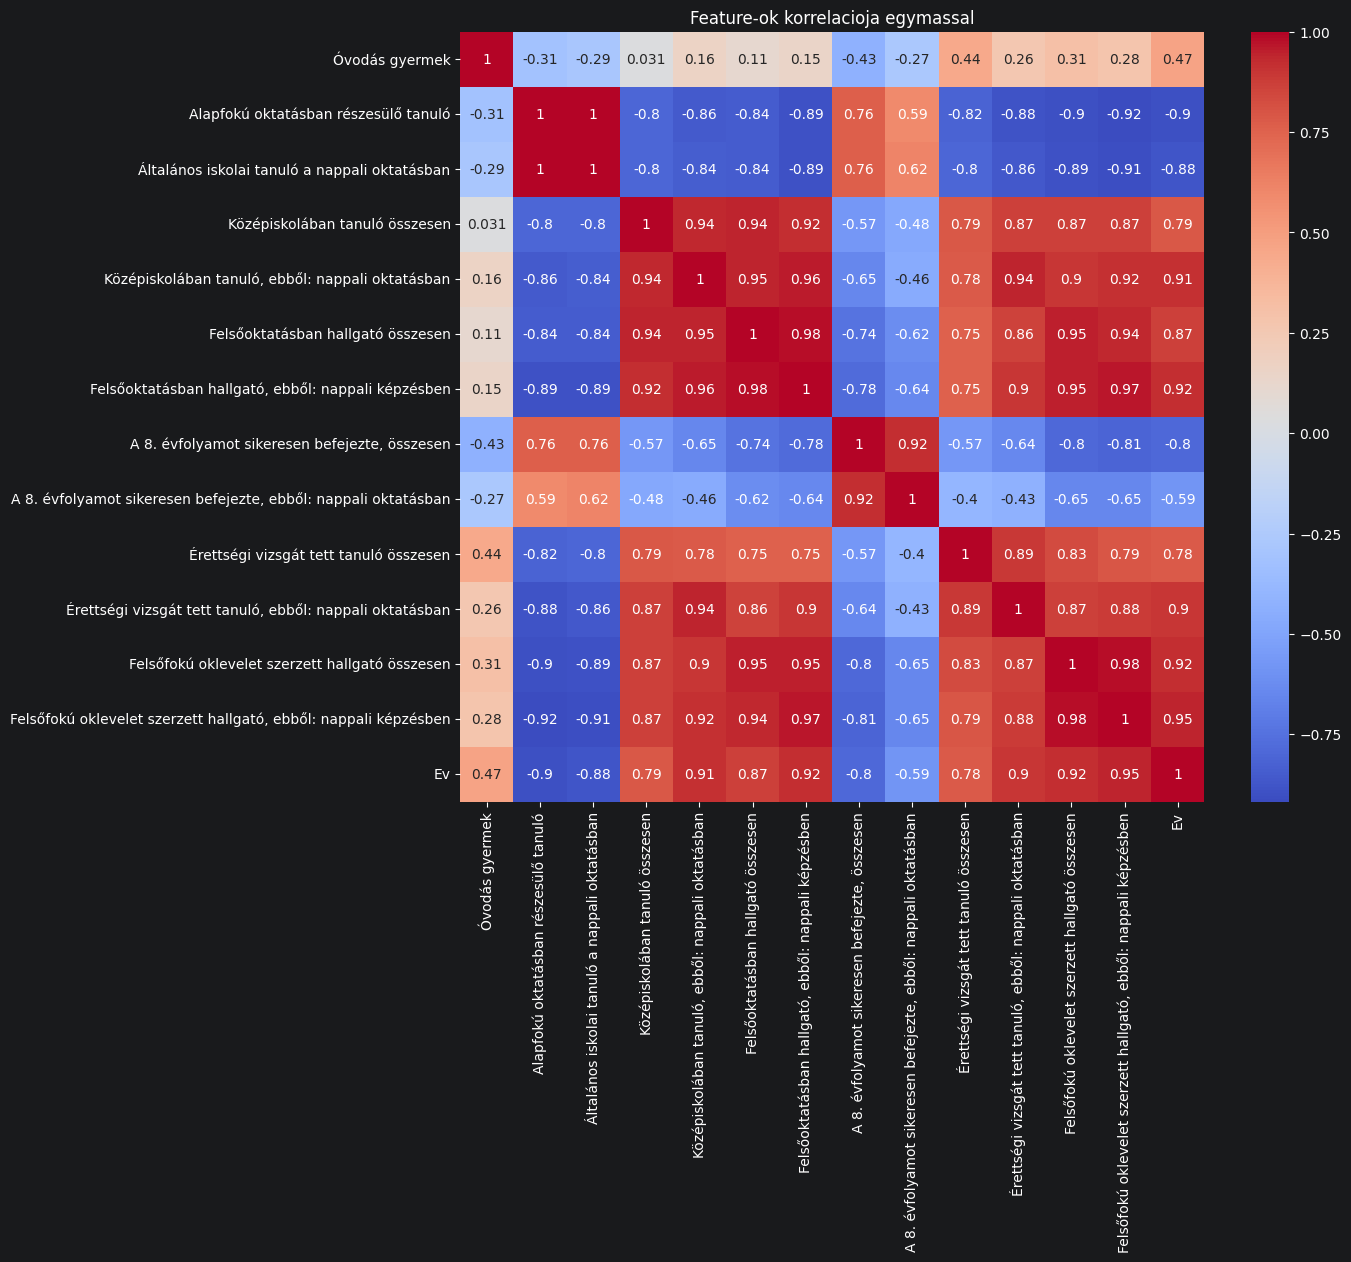

In [2320]:
# Megnezzuk a feature-ok egymassal valo korrelaciojat.
feature_corr = feature_df.drop(columns=["GDP_t_plus_10"]).corr(numeric_only=True)

plt.figure(figsize=(12, 10))
sns.heatmap(feature_corr, annot=True, cmap="coolwarm")
plt.title("Feature-ok korrelacioja egymassal")
plt.show()


- A kozepiskolaban tanulo osszesen, az erettsegi vizsgat tett tanulo osszesen, a felsooktatasban hallgato osszesen es a felsofoku oklevelet szerzett hallgato osszesen valtozok a celvaltozoval ertelmes kapcsolatot mutattak, ezert alkalmas kiindulasi feature-jeloltek.
- Ugyanakkor egymassal is eros korrelacioban allnak, igy a kesobbi szukites soran kozuluk varhatoan nem marad meg mindegyik.

In [2321]:
# Elso feature-szukites: csak a kozepiskola-felsooktatas-diploma lancot tartjuk meg.
feature_df = feature_df[[

    "Felsőoktatásban hallgató összesen",
    "Felsőfokú oklevelet szerzett hallgató összesen",
    "GDP_t_plus_10"
]].copy()

display(feature_df.head())
print(feature_df.shape)


,Felsőoktatásban hallgató összesen,Felsőfokú oklevelet szerzett hallgató összesen,GDP_t_plus_10
0,45,6,168.0
1,53,6,179.0
2,67,7,190.0
3,82,10,203.0
4,92,11,215.0


(55, 3)


# Preprocessing

In [2322]:
# A teljes feature- es targethalmaz szetvalasztasa.
all_features = feature_df.drop(columns=["GDP_t_plus_10"])
all_targets = feature_df["GDP_t_plus_10"]

print("all_features merete:", all_features.shape)
print("all_targets merete:", all_targets.shape)


all_features merete: (55, 2)
all_targets merete: (55,)


In [2323]:
# A teljes adathalmazt train, validation es test halmazokra bontjuk.
n = len(feature_df)

train_end = int(n * 0.70)
val_end = int(n * 0.85)

train_features = all_features.iloc[:train_end].copy()
val_features = all_features.iloc[train_end:val_end].copy()
test_features = all_features.iloc[val_end:].copy()

train_targets = all_targets.iloc[:train_end].copy()
val_targets = all_targets.iloc[train_end:val_end].copy()
test_targets = all_targets.iloc[val_end:].copy()

print("train_features:", train_features.shape)
print("val_features:", val_features.shape)
print("test_features:", test_features.shape)

print("train_targets:", train_targets.shape)
print("val_targets:", val_targets.shape)
print("test_targets:", test_targets.shape)


train_features: (38, 2)
val_features: (8, 2)
test_features: (9, 2)
train_targets: (38,)
val_targets: (8,)
test_targets: (9,)


In [2324]:
from sklearn.preprocessing import StandardScaler

# A feature-okat skálázzuk a train halmaz alapjan.
scaler = StandardScaler()

train_features_scaled = scaler.fit_transform(train_features)
val_features_scaled = scaler.transform(val_features)
test_features_scaled = scaler.transform(test_features)

print(train_features_scaled.shape)
print(val_features_scaled.shape)
print(test_features_scaled.shape)

print("Train scaled - elso 5 sor:")
print(train_features_scaled[:5])

print("Validation scaled - elso 5 sor:")
print(val_features_scaled[:5])

print("Test scaled - elso 5 sor:")
print(test_features_scaled[:5])


(38, 2)
(8, 2)
(9, 2)
Train scaled - elso 5 sor:
[[-1.71259326 -2.35474823]
 [-1.4843476  -2.35474823]
 [-1.08491769 -2.2053652 ]
 [-0.65695708 -1.75721612]
 [-0.37165001 -1.6078331 ]]
Validation scaled - elso 5 sor:
[[4.36444745 2.57489163]
 [4.9635923  3.02304071]
 [6.33306627 3.76995584]
 [6.96074183 3.76995584]
 [7.90225518 4.36748794]]
Test scaled - elso 5 sor:
[[8.87229924 4.666254  ]
 [8.3587465  4.36748794]
 [7.87372447 4.06872189]
 [7.55988669 4.666254  ]
 [7.30311032 4.666254  ]]


# Basic Model Building

In [2325]:
from sklearn.linear_model import LinearRegression

# Elso alapmodell: linearis regresszio.
linear_model = LinearRegression()
linear_model.fit(train_features_scaled, train_targets)


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [2326]:
# A betanitott modell elorejelzest keszit a validation halmazon.
val_predictions = linear_model.predict(val_features_scaled)

print("Az elso 5 becsult ertek:")
print(val_predictions[:5])


Az elso 5 becsult ertek:
[479.59257378 508.46845263 567.83706883 586.8622482  629.68732441]


In [2327]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# A validation halmazon kiszamoljuk az alap hibameroszamokat.
mae = mean_absolute_error(val_targets, val_predictions)
rmse = np.sqrt(mean_squared_error(val_targets, val_predictions))
r2 = r2_score(val_targets, val_predictions)

print("MAE:", mae)
print("RMSE:", rmse)
print("R2:", r2)


MAE: 201.7576064620446
RMSE: 212.62513602147234
R2: -203.5821043598653


In [2328]:
comparison_df = pd.DataFrame({
    "actual": val_targets.values,
    "predicted": val_predictions
}, index=val_targets.index)

display(comparison_df)


,actual,predicted
38,408.0,479.592574
39,380.0,508.468453
40,384.0,567.837069
41,392.0,586.862248
42,386.0,629.687324
43,394.0,660.180062
44,411.0,674.994040
45,426.0,687.439082


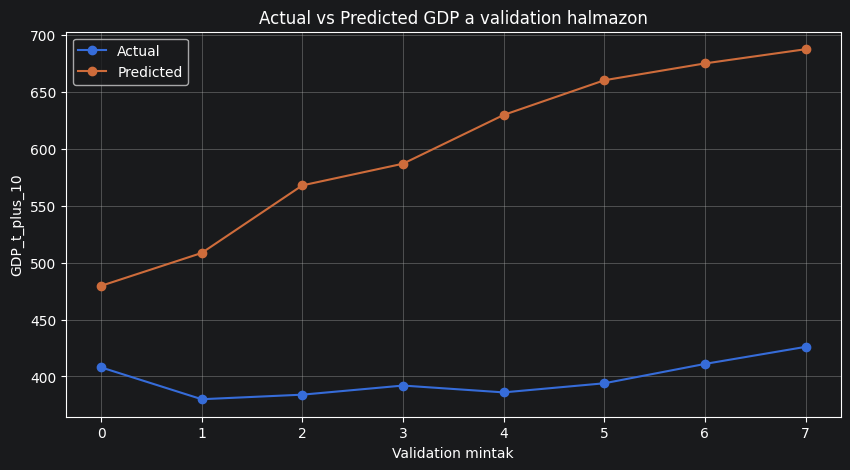

In [2329]:
# Osszehasonlitjuk a valodi es a becsult GDP ertekeket a validation halmazon.
plt.figure(figsize=(10, 5))

plt.plot(val_targets.values, marker="o", label="Actual")
plt.plot(val_predictions, marker="o", label="Predicted")

plt.title("Actual vs Predicted GDP a validation halmazon")
plt.xlabel("Validation mintak")
plt.ylabel("GDP_t_plus_10")
plt.legend()
plt.grid(True)
plt.show()


Sajnos egyszeru linearis regressionnel a model felulbecsul erosen, a kovetkezo lepesben kiprobalunk masik modeleket is.

In [2330]:
from sklearn.linear_model import Ridge

# Kovetkezo alapmodell: Ridge regresszio.
ridge_model = Ridge(alpha=1.0)
ridge_model.fit(train_features_scaled, train_targets)

val_predictions_ridge = ridge_model.predict(val_features_scaled)


In [2331]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# A Ridge modell ellenorzese a validation halmazon.
mae_ridge = mean_absolute_error(val_targets, val_predictions_ridge)
rmse_ridge = np.sqrt(mean_squared_error(val_targets, val_predictions_ridge))
r2_ridge = r2_score(val_targets, val_predictions_ridge)

print("Ridge MAE:", mae_ridge)
print("Ridge RMSE:", rmse_ridge)
print("Ridge R2:", r2_ridge)


Ridge MAE: 196.3175606288883
Ridge RMSE: 207.0655521831379
Ridge R2: -193.02341410295548


In [2332]:
from sklearn.linear_model import Lasso

# Lasso regresszio kiprobalasa.
lasso_model = Lasso(alpha=1.0, random_state=42)
lasso_model.fit(train_features_scaled, train_targets)

val_predictions_lasso = lasso_model.predict(val_features_scaled)


In [2333]:
from sklearn.linear_model import Lasso
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Lasso regresszio kiprobalasa es ellenorzese.
lasso_model = Lasso(alpha=1.0, random_state=42)
lasso_model.fit(train_features_scaled, train_targets)

val_predictions_lasso = lasso_model.predict(val_features_scaled)

mae_lasso = mean_absolute_error(val_targets, val_predictions_lasso)
rmse_lasso = np.sqrt(mean_squared_error(val_targets, val_predictions_lasso))
r2_lasso = r2_score(val_targets, val_predictions_lasso)

print("Lasso MAE:", mae_lasso)
print("Lasso RMSE:", rmse_lasso)
print("Lasso R2:", r2_lasso)


Lasso MAE: 195.29100372574123
Lasso RMSE: 206.032158888106
Lasso R2: -191.09163768295278


In [2334]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Decision Tree regresszio kiprobalasa es ellenorzese.
tree_model = DecisionTreeRegressor(random_state=42)
tree_model.fit(train_features_scaled, train_targets)

val_predictions_tree = tree_model.predict(val_features_scaled)

mae_tree = mean_absolute_error(val_targets, val_predictions_tree)
rmse_tree = np.sqrt(mean_squared_error(val_targets, val_predictions_tree))
r2_tree = r2_score(val_targets, val_predictions_tree)

print("Decision Tree MAE:", mae_tree)
print("Decision Tree RMSE:", rmse_tree)
print("Decision Tree R2:", r2_tree)


Decision Tree MAE: 14.625
Decision Tree RMSE: 16.174826119621812
Decision Tree R2: -0.18390723326027003


# Model Tuning

In [2335]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import pandas as pd

results = []

for max_depth in [2, 3, 4, 5, 6, None]:
    for min_samples_split in [2, 4, 6]:
        for min_samples_leaf in [1, 2, 3]:
            model = DecisionTreeRegressor(
                max_depth=max_depth,
                min_samples_split=min_samples_split,
                min_samples_leaf=min_samples_leaf,
                random_state=42
            )

            model.fit(train_features, train_targets)
            preds = model.predict(val_features)

            mae = mean_absolute_error(val_targets, preds)
            rmse = np.sqrt(mean_squared_error(val_targets, preds))
            r2 = r2_score(val_targets, preds)

            results.append([
                max_depth,
                min_samples_split,
                min_samples_leaf,
                mae,
                rmse,
                r2
            ])

results_df = pd.DataFrame(
    results,
    columns=["max_depth", "min_samples_split", "min_samples_leaf", "MAE", "RMSE", "R2"]
)

# R2 szerint rendezzuk, a legnagyobb legyen legfelul.
display(results_df.sort_values(by="R2", ascending=False).head(10))



,max_depth,min_samples_split,min_samples_leaf,MAE,RMSE,R2
0,2.0,2,1,13.041667,14.865602,-0.000008
1,2.0,2,2,13.041667,14.865602,-0.000008
2,2.0,2,3,13.041667,14.865602,-0.000008
3,2.0,4,1,13.041667,14.865602,-0.000008
4,2.0,4,2,13.041667,14.865602,-0.000008
5,2.0,4,3,13.041667,14.865602,-0.000008
6,2.0,6,1,13.041667,14.865602,-0.000008
7,2.0,6,2,13.041667,14.865602,-0.000008
8,2.0,6,3,13.041667,14.865602,-0.000008
10,3.0,2,2,13.041667,14.865602,-0.000008


# Ensemble Model Building

In [2336]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Ensemble modell: sok decision tree egyutt.
many_trees_model = RandomForestRegressor(
    n_estimators=1000,
    random_state=42
)

many_trees_model.fit(train_features_scaled, train_targets)

many_trees_predictions = many_trees_model.predict(val_features_scaled)

mae_many_trees = mean_absolute_error(val_targets, many_trees_predictions)
rmse_many_trees = np.sqrt(mean_squared_error(val_targets, many_trees_predictions))
r2_many_trees = r2_score(val_targets, many_trees_predictions)

print("Many Trees MAE:", mae_many_trees)
print("Many Trees RMSE:", rmse_many_trees)
print("Many Trees R2:", r2_many_trees)


Many Trees MAE: 13.614999999999995
Many Trees RMSE: 15.047810471959032
Many Trees R2: -0.024672445732871084


# Results

In [ ]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import pandas as pd

# A tuning tablazat legjobb sora alapjan ujra letrehozzuk a legjobb Decision Tree modellt.
best_tree_params = results_df.sort_values(by="R2", ascending=False).iloc[0]

best_max_depth = best_tree_params["max_depth"]
if pd.isna(best_max_depth):
    best_max_depth = None
else:
    best_max_depth = int(best_max_depth)

best_tree_model = DecisionTreeRegressor(
    max_depth=best_max_depth,
    min_samples_split=int(best_tree_params["min_samples_split"]),
    min_samples_leaf=int(best_tree_params["min_samples_leaf"]),
    random_state=42
)

best_tree_model.fit(train_features, train_targets)
best_tree_predictions = best_tree_model.predict(val_features)

best_tree_mae = mean_absolute_error(val_targets, best_tree_predictions)
best_tree_rmse = np.sqrt(mean_squared_error(val_targets, best_tree_predictions))
best_tree_r2 = r2_score(val_targets, best_tree_predictions)

print("Best params:")
print(best_tree_params[["max_depth", "min_samples_split", "min_samples_leaf"]])
print("Best Decision Tree MAE:", round(best_tree_mae, 6))
print("Best Decision Tree RMSE:", round(best_tree_rmse, 6))
print("Best Decision Tree R2:", round(best_tree_r2, 6))


In [2263]:
best_tree_comparison = pd.DataFrame({
    "actual": val_targets.values,
    "predicted": best_tree_predictions,
    "difference": val_targets.values - best_tree_predictions
})

display(best_tree_comparison)


,actual,predicted,difference
0,408.0,397.666667,10.333333
1,380.0,397.666667,-17.666667
2,384.0,397.666667,-13.666667
3,392.0,397.666667,-5.666667
4,386.0,397.666667,-11.666667
5,394.0,397.666667,-3.666667
6,411.0,397.666667,13.333333
7,426.0,397.666667,28.333333


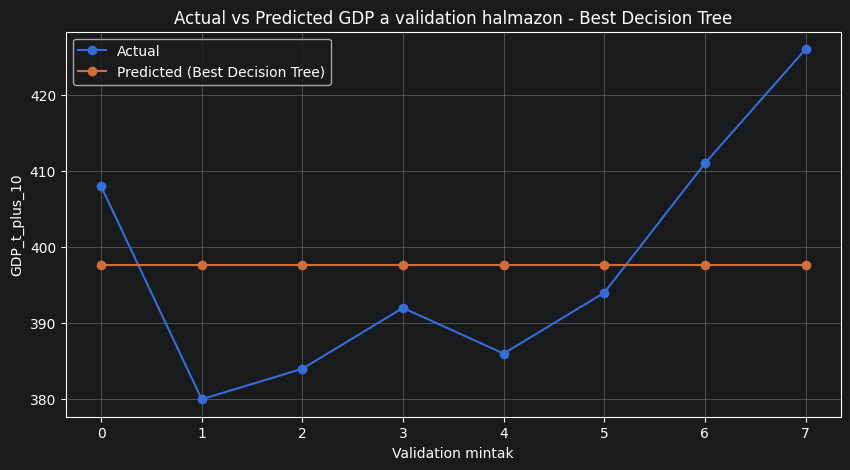

In [2340]:
# Osszehasonlitjuk a valodi es a becsult GDP ertekeket a validation halmazon
plt.figure(figsize=(10, 5))

plt.plot(best_tree_comparison["actual"].values, marker="o", label="Actual")
plt.plot(best_tree_comparison["predicted"].values, marker="o", label="Predicted (Best Decision Tree)")

plt.title("Actual vs Predicted GDP a validation halmazon - Best Decision Tree")
plt.xlabel("Validation mintak")
plt.ylabel("GDP_t_plus_10")
plt.legend()
plt.grid(True)
plt.show()



Kiprobalt modellek:

- LinearRegression
- Ridge
- Lasso
- DecisionTreeRegressor
- RandomForestRegressor

A legjobb eredmenyt a tuningolt DecisionTreeRegressor adta:

- max_depth = 2
- min_samples_split = 2
- min_samples_leaf = 1

- Eredmenyek:

- MAE = 13.04
- RMSE = 14.87
- R2 = -0.000008

Ez azt jelenti, hogy a modell atlagosan kb. 13 GDP-indexpontot teved. Az R2 ertek majdnem nulla, vagyis a modell nem teljesit lenyegesen jobban, mint egy egyszeru atlagos becsles. Emiatt az eredmeny nem tekintheto erosnek. A vizsgalat alapjan az oktatasi adatok es a kesobbi GDP kozott latszik kapcsolat, de ez a kapcsolat onmagaban nem eleg eros ahhoz, hogy jo elorejelzo modellt adjon.

Kovetkeztetes: az alapfelvetes nem bizonyosodott be erosen inkabb csak reszben tamaszthato ala.